In [1]:
"""
================================================================================
  HYBRID FAKE NEWS DETECTION — COMPLETE RESEARCH PIPELINE
  Title : Hybrid Fake News Detection using N-Grams and Sentiment Analysis (VADER)
  Author: [Arnold Makuyana]
  Dataset: Kaggle Fake News Dataset (True.csv + Fake.csv)
 
  PIPELINE ORDER:
    Phase 0  → Imports & Configuration
    Phase 1  → Load & Merge Dataset
    Phase 2  → Advanced Preprocessing
    Phase 3  → Exploratory: Custom Token Stats
    Phase 4  → STEP A: Raw Term Frequency (TF) Analysis
    Phase 5  → STEP B: TF Relevance Table (top words × each article)
    Phase 6  → STEP C: TF-IDF Vectorization (1-gram)
    Phase 7A → 1-gram Sessions (500/2000/5000/10000) — RF, SVM, LR, AdaBoost
    Phase 7B → 2-gram Sessions (500/2000/5000/10000) — RF, SVM, LR, AdaBoost
    Phase 7C → Hybrid VADER Sessions — RF, SVM, LR, AdaBoost
    Phase 8  → Master Comparison Table (64 configurations)
    Phase 9  → Confusion Matrices (all configurations)
================================================================================
"""

'\n================================================================================\n  HYBRID FAKE NEWS DETECTION — COMPLETE RESEARCH PIPELINE\n  Title : Hybrid Fake News Detection using N-Grams and Sentiment Analysis (VADER)\n  Author: [Arnold Makuyana]\n  Dataset: Kaggle Fake News Dataset (True.csv + Fake.csv)\n\n  PIPELINE ORDER:\n    Phase 0  → Imports & Configuration\n    Phase 1  → Load & Merge Dataset\n    Phase 2  → Advanced Preprocessing\n    Phase 3  → Exploratory: Custom Token Stats\n    Phase 4  → STEP A: Raw Term Frequency (TF) Analysis\n    Phase 5  → STEP B: TF Relevance Table (top words × each article)\n    Phase 6  → STEP C: TF-IDF Vectorization (1-gram)\n    Phase 7A → 1-gram Sessions (500/2000/5000/10000) — RF, SVM, LR, AdaBoost\n    Phase 7B → 2-gram Sessions (500/2000/5000/10000) — RF, SVM, LR, AdaBoost\n    Phase 7C → Hybrid VADER Sessions — RF, SVM, LR, AdaBoost\n    Phase 8  → Master Comparison Table (64 configurations)\n    Phase 9  → Confusion Matrices (all co

In [2]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# PHASE 0 — IMPORTS & CONFIGURATION
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
 
from collections import Counter
from scipy.sparse import hstack, csr_matrix
 
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                              recall_score, classification_report,
                              confusion_matrix)
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from nltk.sentiment.vader import SentimentIntensityAnalyzer
 
warnings.filterwarnings("ignore")

In [3]:
for pkg in ['wordnet', 'omw-1.4', 'stopwords', 'vader_lexicon']:
    nltk.download(pkg, quiet=True)

In [4]:
RANDOM_STATE    = 42
TEST_SIZE       = 0.20
MAX_FEATURES    = 5000
CV_FOLDS        = 5
SAMPLE_TABLE_N  = 20
TOP_WORDS_N     = 15
TOP_CHART_N     = 20
DISPLAY_N       = 20
DISPLAY_WORDS   = 15
VOCAB_SESSIONS  = [500, 2000, 5000, 10000]
 
print("=" * 72)
print("  HYBRID FAKE NEWS DETECTION PIPELINE — INITIALISED")
print("=" * 72)

  HYBRID FAKE NEWS DETECTION PIPELINE — INITIALISED


In [5]:
print("\n[PHASE 1] Loading Dataset...")
 
df_fake = pd.read_csv(r"C:\Users\WELCOME\Documents\True.csv\Fake.csv")
df_real = pd.read_csv(r"C:\Users\WELCOME\Documents\True.csv\True.csv")
 
df_real["label"] = "REAL"
df_fake["label"] = "FAKE"
 
df = pd.concat([df_real, df_fake], ignore_index=True)
df = df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
 
print(f"  Total articles loaded : {len(df):,}")
print(f"  REAL                  : {(df['label']=='REAL').sum():,}")
print(f"  FAKE                  : {(df['label']=='FAKE').sum():,}")
print(f"  Columns               : {list(df.columns)}")


[PHASE 1] Loading Dataset...
  Total articles loaded : 44,898
  REAL                  : 21,417
  FAKE                  : 23,481
  Columns               : ['title', 'text', 'subject', 'date', 'label']


In [6]:
print("\n[PHASE 2] Preprocessing...")
 
lemmatizer = WordNetLemmatizer()
stop_words  = set(stopwords.words('english'))
KEEP_TOKENS = {'num_token', 'multi_exclamation', 'multi_question'}
 
def advanced_clean(text: str) -> str:
    if not isinstance(text, str) or not text.strip():
        return ""
    text = re.sub(r"^[A-Z][A-Z\s,\.]{1,30}\([^)]{2,15}\)\s*[-\u2013\u2014]\s*", "", text.strip())
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"!{2,}", " multi_exclamation ", text)
    text = re.sub(r"\?{2,}", " multi_question ", text)
    text = re.sub(r"\b\d[\d,\.]*\b", " num_token ", text)
    contractions = {"can't": "cannot", "won't": "will not", "n't": " not",
                    "'re": " are", "'ve": " have", "'ll": " will",
                    "'d": " would", "'m": " am"}
    for pat, repl in contractions.items():
        text = text.replace(pat, repl)
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s_]", " ", text)
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(t) if t not in KEEP_TOKENS else t
              for t in tokens if t not in stop_words or t in KEEP_TOKENS]
    return " ".join(tokens)
 
df["combined_raw"] = df["title"].fillna("") + " " + df["text"].fillna("")
df["clean_text"]   = df["combined_raw"].apply(advanced_clean)
 
initial = len(df)
df = df.drop_duplicates(subset=["clean_text"])
df = df[df["clean_text"].str.split().str.len() > 10].reset_index(drop=True)
 
print(f"  Removed {initial - len(df):,} duplicates / short articles")
print(f"  Final corpus size     : {len(df):,}")
print(df["label"].value_counts(normalize=True).to_string())
print(f"\n  Sample: {df['clean_text'].iloc[0][:200]}...")


[PHASE 2] Preprocessing...
  Removed 6,351 duplicates / short articles
  Final corpus size     : 38,547
label
REAL    0.542844
FAKE    0.457156

  Sample: breaking gop chairman grassley enough demand trump jr testimony donald trump white house chaos trying cover russia problem mounting hour refuse acknowledge problem surrounding fake news hoax however f...



[PHASE 3] Custom Token Frequency (Tone Signals)...
            Token  FAKE   REAL
Exclamations (!!)   391      9
   Questions (??)   462      3
          Numbers 87558 106133


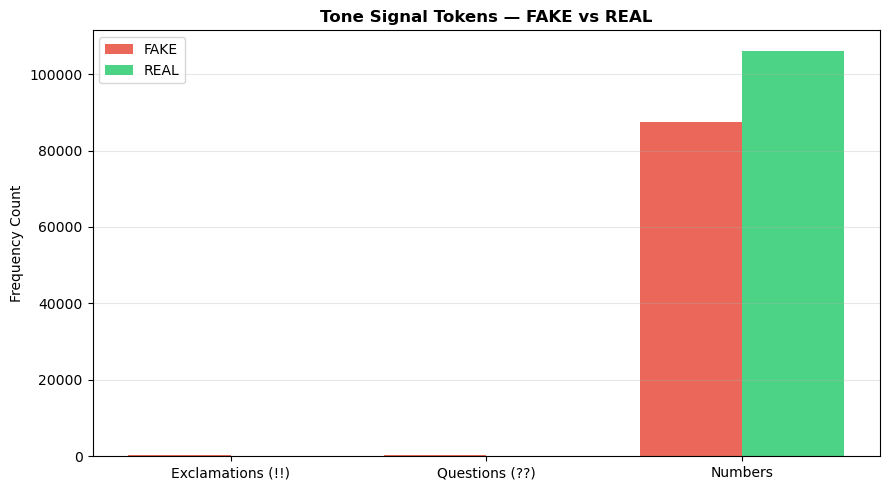

  [Saved] tone_tokens.png


In [7]:
print("\n[PHASE 3] Custom Token Frequency (Tone Signals)...")
 
def token_stats(df, label):
    text = " ".join(df[df["label"] == label]["clean_text"])
    c = Counter(text.split())
    return {t: c.get(t, 0) for t in ["multi_exclamation", "multi_question", "num_token"]}
 
fake_stats = token_stats(df, "FAKE")
real_stats = token_stats(df, "REAL")
 
tone_df = pd.DataFrame({
    "Token": ["Exclamations (!!)", "Questions (??)", "Numbers"],
    "FAKE" : [fake_stats["multi_exclamation"], fake_stats["multi_question"], fake_stats["num_token"]],
    "REAL" : [real_stats["multi_exclamation"], real_stats["multi_question"], real_stats["num_token"]],
})
print(tone_df.to_string(index=False))
 
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(3)
ax.bar(x - 0.2, tone_df["FAKE"], 0.4, label="FAKE", color="#e74c3c", alpha=0.85)
ax.bar(x + 0.2, tone_df["REAL"], 0.4, label="REAL", color="#2ecc71", alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(tone_df["Token"])
ax.set_title("Tone Signal Tokens — FAKE vs REAL", fontweight="bold")
ax.set_ylabel("Frequency Count"); ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.savefig("tone_tokens.png", dpi=150); plt.show()
print("  [Saved] tone_tokens.png")


  STEP A — RAW TERM FREQUENCY (TF) ANALYSIS

Top 20 Most Frequent Terms (raw TF, entire corpus):

          word  total_count
1    num_token       193691
2        trump       134273
3         said       121426
4        state        54817
5    president        50497
6   republican        39195
7       people        36776
8         year        36718
9      reuters        28735
10         new        28460
11       house        27096
12  government        26618
13      donald        26244
14         say        25580
15       obama        25038
16     clinton        24873
17        time        24522
18    election        23221
19     country        22487
20       party        22148


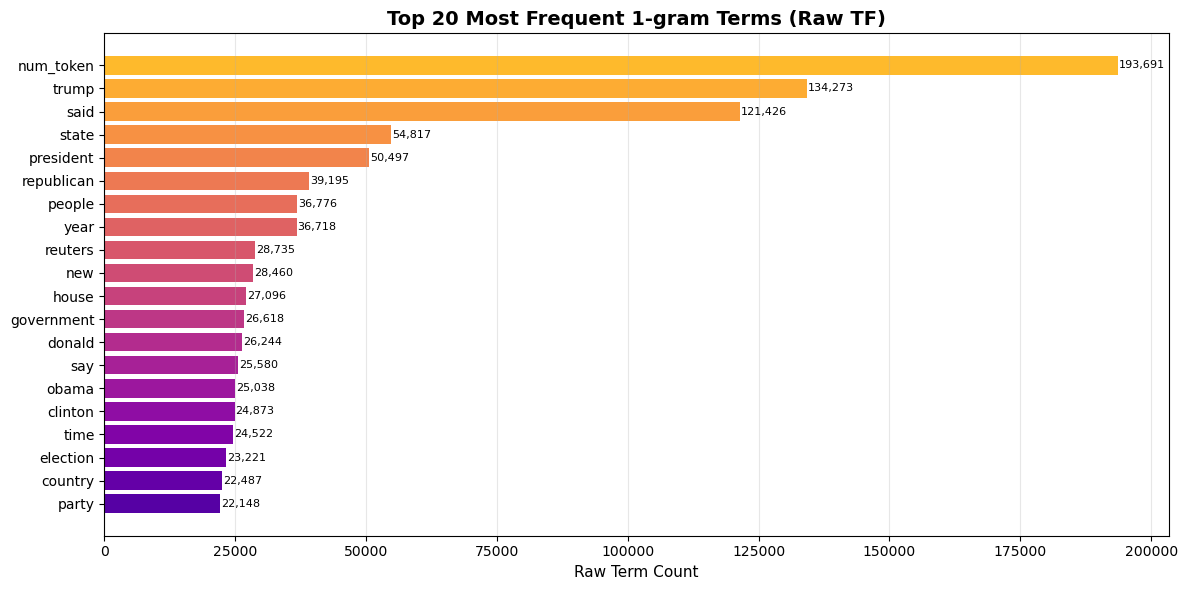

  [Saved] step_A_tf_top_words.png


In [8]:
print("\n" + "=" * 72)
print("  STEP A — RAW TERM FREQUENCY (TF) ANALYSIS")
print("=" * 72)
 
count_vec = CountVectorizer(max_features=MAX_FEATURES, stop_words="english", min_df=3)
count_matrix = count_vec.fit_transform(df["clean_text"])
count_features = count_vec.get_feature_names_out()
 
tf_sums = np.array(count_matrix.sum(axis=0)).flatten()
tf_df = pd.DataFrame({"word": count_features, "total_count": tf_sums})
tf_df = tf_df.sort_values("total_count", ascending=False).reset_index(drop=True)
tf_df.index += 1
 
print(f"\nTop {TOP_CHART_N} Most Frequent Terms (raw TF, entire corpus):\n")
print(tf_df.head(TOP_CHART_N).to_string())
 
fig, ax = plt.subplots(figsize=(12, 6))
data = tf_df.head(TOP_CHART_N)
colors = plt.cm.plasma(np.linspace(0.15, 0.85, TOP_CHART_N))
bars = ax.barh(data["word"][::-1], data["total_count"][::-1], color=colors)
ax.set_xlabel("Raw Term Count", fontsize=11)
ax.set_title(f"Top {TOP_CHART_N} Most Frequent 1-gram Terms (Raw TF)", fontsize=14, fontweight="bold")
ax.grid(axis="x", alpha=0.3)
for bar, val in zip(bars, data["total_count"][::-1]):
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2, f"{int(val):,}", va="center", fontsize=8)
plt.tight_layout(); plt.savefig("step_A_tf_top_words.png", dpi=150); plt.show()
print("  [Saved] step_A_tf_top_words.png")

In [9]:
print("\n" + "=" * 72)
print("  STEP B — TF RELEVANCE TABLE (Top Words × Each Article)")
print("=" * 72)
 
top_tf_words = tf_df["word"].head(TOP_WORDS_N).tolist()
real_sample = df[df["label"] == "REAL"].head(SAMPLE_TABLE_N // 2).copy()
fake_sample = df[df["label"] == "FAKE"].head(SAMPLE_TABLE_N // 2).copy()
sample_df   = pd.concat([real_sample, fake_sample]).reset_index(drop=True)
 
tf_rows = []
for _, row in sample_df.iterrows():
    token_counts = Counter(row["clean_text"].split())
    entry = {"article_id": len(tf_rows)+1, "label": row["label"],
             "snippet": row["clean_text"][:50]+"..."}
    for w in top_tf_words:
        entry[w] = token_counts.get(w, 0)
    tf_rows.append(entry)
 
tf_relevance_df = pd.DataFrame(tf_rows)
tf_relevance_df.to_csv("step_B_tf_relevance_table.csv", index=False)
print(f"\nTF Relevance Table ({SAMPLE_TABLE_N} articles × top {TOP_WORDS_N} words):\n")
print(tf_relevance_df[["article_id","label"]+top_tf_words].to_string(index=False))
print("\n  [Saved] step_B_tf_relevance_table.csv")


  STEP B — TF RELEVANCE TABLE (Top Words × Each Article)

TF Relevance Table (20 articles × top 15 words):

 article_id label  num_token  trump  said  state  president  republican  people  year  reuters  new  house  government  donald  say  obama
          1  REAL          0      3     1      0          0           0       1     0        2    1      0           0       0    0      0
          2  REAL         10      7     7      0          4           2       1     1        1    1      1           1       1    0      1
          3  REAL          1      0     2      0          1           0       0     0        1    0      0           0       0    0      0
          4  REAL          8      0     4      2          0           0       0     2        1    0      0           2       0    3      0
          5  REAL          2      0     3      0          1           0       3     1        1    0      0           0       0    3      0
          6  REAL          1      7     6      2         


  STEP C — TF-IDF VECTORIZATION (1-GRAM, corpus inspection only)

  TF-IDF Matrix shape : (38547, 5000)
  Sparsity            : 97.5813%


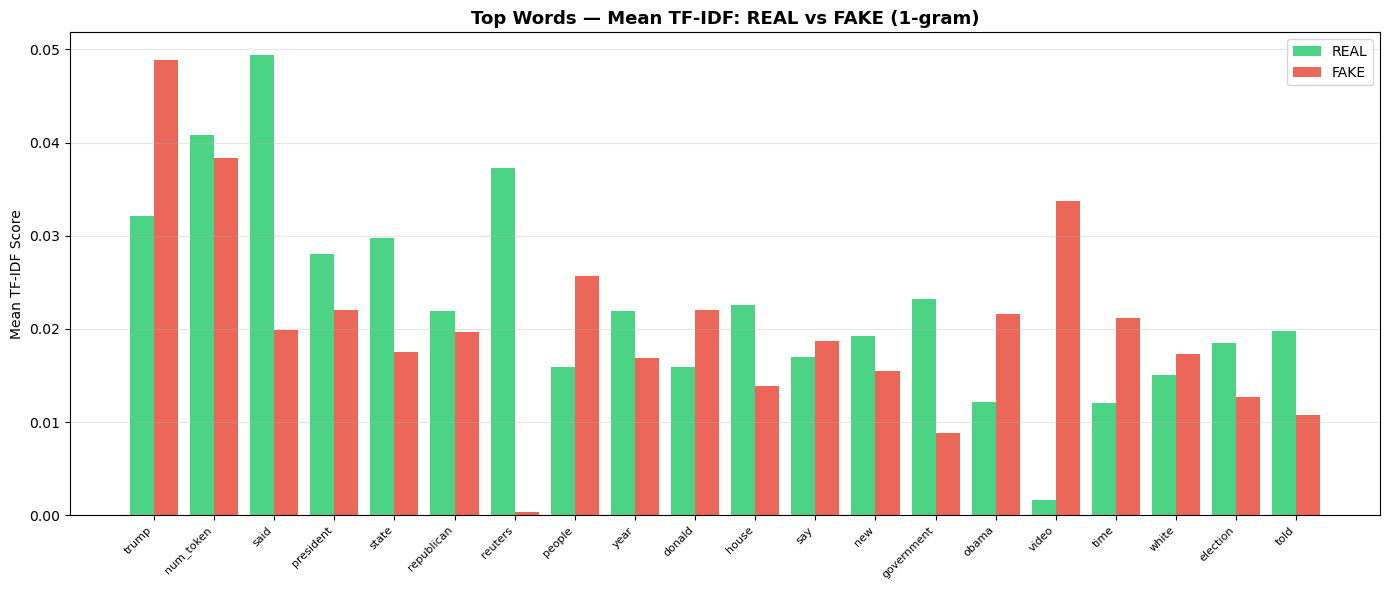

  [Saved] step_C_tfidf_comparison.png


In [10]:
print("\n" + "=" * 72)
print("  STEP C — TF-IDF VECTORIZATION (1-GRAM, corpus inspection only)")
print("=" * 72)
 
tfidf_1gram = TfidfVectorizer(
    ngram_range=(1,1), max_features=MAX_FEATURES, sublinear_tf=True,
    strip_accents="unicode", analyzer="word", stop_words="english",
    min_df=3, max_df=0.95
)
X_tfidf_full = tfidf_1gram.fit_transform(df["clean_text"])
feature_names_1gram = tfidf_1gram.get_feature_names_out()
 
print(f"\n  TF-IDF Matrix shape : {X_tfidf_full.shape}")
sparsity = 1 - X_tfidf_full.nnz / (X_tfidf_full.shape[0] * X_tfidf_full.shape[1])
print(f"  Sparsity            : {sparsity:.4%}")
 
mean_tfidf_all = np.array(X_tfidf_full.mean(axis=0)).flatten()
top_tfidf_idx  = mean_tfidf_all.argsort()[::-1][:TOP_CHART_N]
top_tfidf_words = feature_names_1gram[top_tfidf_idx]
 
real_mask = df["label"].values == "REAL"
fake_mask = df["label"].values == "FAKE"
real_means = np.array(X_tfidf_full[real_mask][:, top_tfidf_idx].mean(axis=0)).flatten()
fake_means = np.array(X_tfidf_full[fake_mask][:, top_tfidf_idx].mean(axis=0)).flatten()
 
x = np.arange(TOP_CHART_N)
fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - 0.2, real_means, 0.4, label="REAL", color="#2ecc71", alpha=0.85)
ax.bar(x + 0.2, fake_means, 0.4, label="FAKE", color="#e74c3c", alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(top_tfidf_words, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Mean TF-IDF Score")
ax.set_title("Top Words — Mean TF-IDF: REAL vs FAKE (1-gram)", fontsize=13, fontweight="bold")
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.savefig("step_C_tfidf_comparison.png", dpi=150); plt.show()
print("  [Saved] step_C_tfidf_comparison.png")

## Phase 7A — 1-gram Sessions
Training on TF-IDF Relevance Matrix at 4 vocabulary sizes × 4 classifiers

In [11]:
# ── SHUFFLE & STRATIFICATION VERIFICATION ────────────────────────────────────
print("=" * 72)
print("  SHUFFLE & STRATIFICATION VERIFICATION")
print("=" * 72)
 
label_runs = (df["label"] != df["label"].shift()).sum()
print(f"\n  Label-change transitions: {label_runs:,}")
if label_runs < 100:
    print("  ⚠  Re-shuffling df...")
    df = df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
print("  ✓  Shuffle confirmed.")
 
X_text = df["clean_text"]
y      = df["label"]
 
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
 
train_counts = y_train.value_counts()
test_counts  = y_test.value_counts()
train_total  = len(y_train)
test_total   = len(y_test)
 
print(f"\n  Train: {train_total:,}  |  Test: {test_total:,}")
print(f"  Train REAL={train_counts.get('REAL',0)/train_total*100:.1f}%  FAKE={train_counts.get('FAKE',0)/train_total*100:.1f}%")
 
assert 40 <= train_counts.get("REAL",0)/train_total*100 <= 60, "FATAL: imbalanced"
assert 40 <= train_counts.get("FAKE",0)/train_total*100 <= 60, "FATAL: imbalanced"
print("  ✓  Both splits class-balanced.\n")

  SHUFFLE & STRATIFICATION VERIFICATION

  Label-change transitions: 19,070
  ✓  Shuffle confirmed.

  Train: 30,837  |  Test: 7,710
  Train REAL=54.3%  FAKE=45.7%
  ✓  Both splits class-balanced.



In [12]:
def stratified_display_sample(y_arr, n_each=10):
    real_pos = np.where(y_arr == "REAL")[0]
    fake_pos = np.where(y_arr == "FAKE")[0]
    assert len(real_pos) >= n_each and len(fake_pos) >= n_each
    return real_pos[:n_each].tolist(), fake_pos[:n_each].tolist()
 
def evaluate_model(model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    return {
        "accuracy"  : accuracy_score(y_te, y_pred),
        "precision" : precision_score(y_te, y_pred, average="weighted", zero_division=0),
        "recall"    : recall_score(y_te, y_pred, average="weighted", zero_division=0),
        "f1"        : f1_score(y_te, y_pred, average="weighted", zero_division=0),
        "y_pred"    : y_pred,
    }
 
def plot_cm(y_true, y_pred, title, save_path, cmap="Blues"):
    cm = confusion_matrix(y_true, y_pred, labels=["FAKE", "REAL"])
    fig, ax = plt.subplots(figsize=(4.5, 3.8))
    sns.heatmap(cm, annot=True, fmt="d", cmap=cmap,
                xticklabels=["FAKE","REAL"], yticklabels=["FAKE","REAL"], ax=ax)
    ax.set_title(title, fontsize=9, fontweight="bold")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    plt.tight_layout(); plt.savefig(save_path, dpi=150); plt.close()
    print(f"  [Saved] {save_path}")
 
# ── All 4 classifiers ─────────────────────────────────────────────────────────
def get_models():
    return [
        ("Random Forest",
         RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=RANDOM_STATE)),
        ("SVM",
         LinearSVC(C=1.0, max_iter=2000, random_state=RANDOM_STATE)),
        ("Logistic Regression",
         LogisticRegression(solver="saga", penalty="l2", C=1.0,
                            max_iter=1000, n_jobs=-1, random_state=RANDOM_STATE)),
        ("AdaBoost",
         AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),
                            n_estimators=200, learning_rate=1.0,
                            algorithm="SAMME", random_state=RANDOM_STATE)),
    ]
 
print("  ✓  Helper functions and get_models() defined.")

  ✓  Helper functions and get_models() defined.


In [13]:
all_session_results = []
y_train_arr = y_train.values
 
for session_num, vocab_size in enumerate(VOCAB_SESSIONS, 1):
    print("\n" + "█" * 72)
    print(f"  1-GRAM SESSION {session_num}/4 — vocab={vocab_size:,}  |  4 classifiers")
    print("█" * 72)
 
    vectoriser = TfidfVectorizer(
        ngram_range=(1,1), max_features=vocab_size, sublinear_tf=True,
        strip_accents="unicode", analyzer="word", stop_words="english",
        min_df=3, max_df=0.95
    )
    X_train_sparse = vectoriser.fit_transform(X_train_text)
    X_test_sparse  = vectoriser.transform(X_test_text)
    feature_names  = vectoriser.get_feature_names_out()
    sparsity = 1 - X_train_sparse.nnz / (X_train_sparse.shape[0] * X_train_sparse.shape[1])
    print(f"  Vocab={len(feature_names):,}  Matrix={X_train_sparse.shape}  Sparsity={sparsity:.2%}")
 
    # ── TF-IDF Relevance Table (display) ──────────────────────────────────
    mean_tfidf_tr = np.array(X_train_sparse.mean(axis=0)).flatten()
    real_mean_w = np.array(X_train_sparse[y_train_arr=="REAL"].mean(axis=0)).flatten()
    fake_mean_w = np.array(X_train_sparse[y_train_arr=="FAKE"].mean(axis=0)).flatten()
    top_idx  = mean_tfidf_tr.argsort()[::-1][:DISPLAY_WORDS]
    top_cols = feature_names[top_idx].tolist()
 
    real_loc, fake_loc = stratified_display_sample(y_train_arr, n_each=DISPLAY_N//2)
    disp_idx   = real_loc + fake_loc
    samp_labels = [y_train_arr[i] for i in disp_idx]
    X_disp = X_train_sparse[disp_idx][:, top_idx].toarray()
    disp_df = pd.DataFrame(X_disp, columns=top_cols)
    disp_df.insert(0, "label", samp_labels)
    disp_df.insert(0, "article_id", range(1, DISPLAY_N+1))
    print(f"\n  TF-IDF Relevance Table (vocab={vocab_size:,}):")
    print(disp_df.round(4).to_string(index=False))
    disp_df.to_csv(f"tfidf_relevance_table_vocab{vocab_size}.csv", index=False)
 
    # ── Dense matrix ──────────────────────────────────────────────────────
    X_tr = X_train_sparse.toarray()
    X_te = X_test_sparse.toarray()
    print(f"\n  Training matrix: {X_tr.shape}  (~{X_tr.nbytes/1e6:.0f} MB)")
 
    # ── Train all 4 classifiers ───────────────────────────────────────────
    for model_name, model in get_models():
        print(f"\n  ── {model_name} | 1-gram | vocab={vocab_size:,} ──")
        res = evaluate_model(model, X_tr, X_te, y_train, y_test)
        print(f"  Accuracy={res['accuracy']:.4f}  F1={res['f1']:.4f}")
        print(classification_report(y_test, res["y_pred"],
                                    target_names=["FAKE","REAL"], digits=4, zero_division=0))
        plot_cm(y_test, res["y_pred"],
                f"{model_name} | 1-gram | vocab={vocab_size:,}",
                f"cm_1gram_{model_name.replace(' ','_')}_vocab{vocab_size}.png")
        all_session_results.append({
            "Session": session_num, "Vocab Size": vocab_size,
            "N-gram": "1-gram", "Model": model_name,
            "Accuracy": round(res["accuracy"],4), "Precision": round(res["precision"],4),
            "Recall": round(res["recall"],4), "F1-Score": round(res["f1"],4),
        })
    print(f"  ✓ Session {session_num}/4 complete.")


████████████████████████████████████████████████████████████████████████
  1-GRAM SESSION 1/4 — vocab=500  |  4 classifiers
████████████████████████████████████████████████████████████████████████
  Vocab=500  Matrix=(30837, 500)  Sparsity=88.84%

  TF-IDF Relevance Table (vocab=500):
 article_id label  num_token  trump   said  president  state  people  reuters  republican   year  donald    say  house    new  government  video
          1  REAL     0.0000 0.0000 0.0978     0.0593 0.0000  0.0671   0.0589      0.0000 0.0662  0.0000 0.0000 0.0000 0.0739      0.0000 0.0000
          2  REAL     0.0521 0.0000 0.0909     0.0000 0.0000  0.0000   0.1619      0.0000 0.0000  0.0000 0.0807 0.0000 0.0000      0.0000 0.0000
          3  REAL     0.0866 0.0000 0.1043     0.0000 0.1409  0.0910   0.0472      0.1061 0.0899  0.0000 0.0562 0.0652 0.0000      0.0000 0.0000
          4  REAL     0.1217 0.0000 0.1062     0.0518 0.0000  0.0000   0.1080      0.0000 0.0000  0.0000 0.0612 0.0000 0.1353      0.

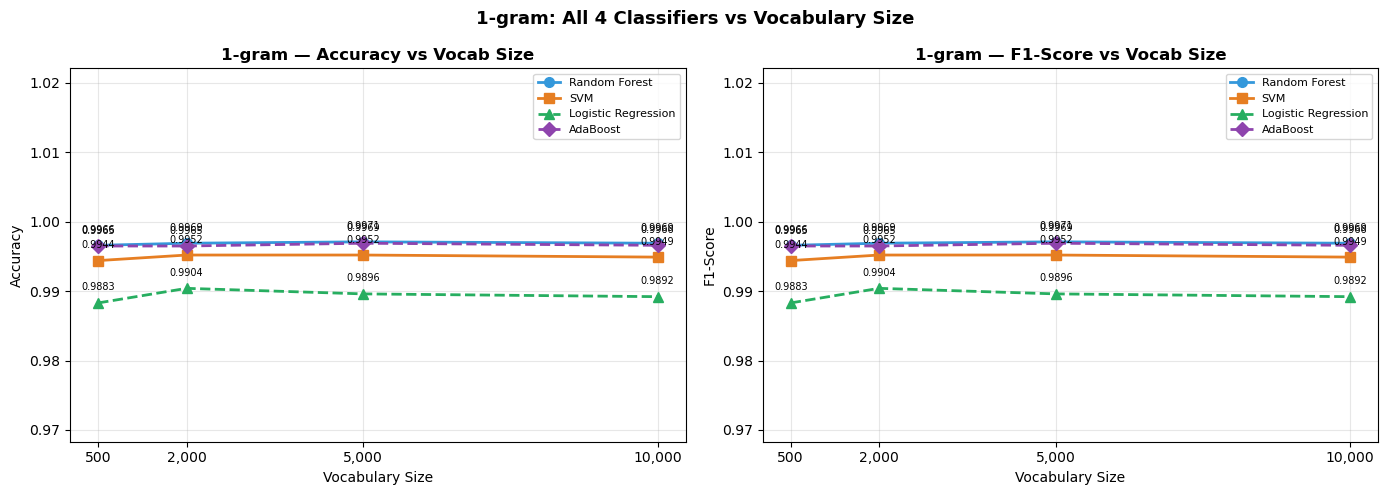

  [Saved] 1gram_all_models_performance.png


In [14]:
summary_df = pd.DataFrame(all_session_results)
summary_df.to_csv("summary_1gram_all_models.csv", index=False)
 
MODEL_STYLES = {
    "Random Forest"      : {"color": "#3498db", "marker": "o",  "ls": "-"},
    "SVM"                : {"color": "#e67e22", "marker": "s",  "ls": "-"},
    "Logistic Regression": {"color": "#27ae60", "marker": "^",  "ls": "--"},
    "AdaBoost"           : {"color": "#8e44ad", "marker": "D",  "ls": "--"},
}
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, metric in zip(axes, ["Accuracy", "F1-Score"]):
    for mn, style in MODEL_STYLES.items():
        sub = summary_df[summary_df["Model"] == mn].sort_values("Vocab Size")
        if sub.empty: continue
        ax.plot(sub["Vocab Size"], sub[metric], label=mn,
                color=style["color"], marker=style["marker"],
                linestyle=style["ls"], linewidth=2, markersize=7)
        for _, r in sub.iterrows():
            ax.annotate(f"{r[metric]:.4f}", (r["Vocab Size"], r[metric]),
                        textcoords="offset points", xytext=(0,9), ha="center", fontsize=7)
    ax.set_title(f"1-gram — {metric} vs Vocab Size", fontweight="bold")
    ax.set_xlabel("Vocabulary Size"); ax.set_ylabel(metric)
    ax.set_xticks(VOCAB_SESSIONS)
    ax.set_xticklabels([f"{v:,}" for v in VOCAB_SESSIONS])
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
    y_all = summary_df[metric].values
    ax.set_ylim(y_all.min()-0.02, y_all.max()+0.025)
 
plt.suptitle("1-gram: All 4 Classifiers vs Vocabulary Size", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("1gram_all_models_performance.png", dpi=150, bbox_inches="tight")
plt.show()
print("  [Saved] 1gram_all_models_performance.png")

## Phase 7B — 2-gram Sessions
Training on 2-gram TF-IDF Relevance Matrix × 4 classifiers × 4 vocabulary sizes

In [15]:
all_2gram_results = []
 
for session_num, vocab_size in enumerate(VOCAB_SESSIONS, 1):
    print("\n" + "█" * 72)
    print(f"  2-GRAM SESSION {session_num}/4 — vocab={vocab_size:,}  |  4 classifiers")
    print("█" * 72)
 
    vec2 = TfidfVectorizer(
        ngram_range=(2,2), max_features=vocab_size, sublinear_tf=True,
        strip_accents="unicode", analyzer="word", stop_words="english",
        min_df=5, max_df=0.90
    )
    X_train_sp2 = vec2.fit_transform(X_train_text)
    X_test_sp2  = vec2.transform(X_test_text)
    feat2 = vec2.get_feature_names_out()
    actual2 = len(feat2)
    sparsity2 = 1 - X_train_sp2.nnz / (X_train_sp2.shape[0] * X_train_sp2.shape[1])
    print(f"  Actual vocab={actual2:,}  Matrix={X_train_sp2.shape}  Sparsity={sparsity2:.2%}")
    if actual2 < vocab_size:
        print(f"  ⚠  {actual2:,} bigrams (normal — min_df=5 filters rare bigrams)")
 
    # ── 2-gram Relevance Table ────────────────────────────────────────────
    mean2 = np.array(X_train_sp2.mean(axis=0)).flatten()
    top2_idx  = mean2.argsort()[::-1][:min(DISPLAY_WORDS, actual2)]
    top2_cols = feat2[top2_idx].tolist()
    real_loc2, fake_loc2 = stratified_display_sample(y_train_arr, n_each=DISPLAY_N//2)
    disp2_idx = real_loc2 + fake_loc2
    samp2_labels = [y_train_arr[i] for i in disp2_idx]
    X_disp2 = X_train_sp2[disp2_idx][:, top2_idx].toarray()
    disp2_df = pd.DataFrame(X_disp2, columns=top2_cols)
    disp2_df.insert(0, "label", samp2_labels)
    disp2_df.insert(0, "article_id", range(1, DISPLAY_N+1))
    print(f"\n  2-gram Relevance Table (vocab={vocab_size:,}):")
    print(disp2_df.round(4).to_string(index=False))
    disp2_df.to_csv(f"tfidf_2gram_relevance_table_vocab{vocab_size}.csv", index=False)
 
    X_tr2 = X_train_sp2.toarray()
    X_te2 = X_test_sp2.toarray()
 
    for model_name, model in get_models():
        print(f"\n  ── {model_name} | 2-gram | vocab={vocab_size:,} ──")
        res = evaluate_model(model, X_tr2, X_te2, y_train, y_test)
        print(f"  Accuracy={res['accuracy']:.4f}  F1={res['f1']:.4f}")
        print(classification_report(y_test, res["y_pred"],
                                    target_names=["FAKE","REAL"], digits=4, zero_division=0))
        plot_cm(y_test, res["y_pred"],
                f"{model_name} | 2-gram | vocab={vocab_size:,}",
                f"cm_2gram_{model_name.replace(' ','_')}_vocab{vocab_size}.png", cmap="Oranges")
        all_2gram_results.append({
            "Session": session_num, "Vocab Size": vocab_size,
            "N-gram": "2-gram", "Model": model_name,
            "Accuracy": round(res["accuracy"],4), "Precision": round(res["precision"],4),
            "Recall": round(res["recall"],4), "F1-Score": round(res["f1"],4),
        })
    print(f"  ✓ Session {session_num}/4 complete.")
 
summary_2gram = pd.DataFrame(all_2gram_results)
summary_2gram.to_csv("summary_2gram_all_models.csv", index=False)
print("\n  [Saved] summary_2gram_all_models.csv")


████████████████████████████████████████████████████████████████████████
  2-GRAM SESSION 1/4 — vocab=500  |  4 classifiers
████████████████████████████████████████████████████████████████████████
  Actual vocab=500  Matrix=(30837, 500)  Sparsity=97.59%

  2-gram Relevance Table (vocab=500):
 article_id label  donald trump  num_token num_token  united state  white house  num_token year  featured image  num_token percent  num_token million  hillary clinton  washington reuters  president donald  new york  prime minister  year old  said statement
          1  REAL        0.0000               0.0000        0.0000       0.0000          0.0000          0.0000             0.0000             0.0000              0.0              0.0000            0.0000    0.0000             0.0    0.0000             0.0
          2  REAL        0.0000               0.0000        0.0000       0.0000          0.0000          0.0000             0.0000             0.0000              0.0              0.0000      

## Phase 7C — Hybrid VADER Sessions
TF-IDF + VADER feature fusion × 4 classifiers × 4 vocabulary sizes × 2 N-gram types

  STEP 1 — VADER SENTIMENT EXTRACTION (computed once, aligned)
  Computing VADER scores for training set...
  Train VADER shape : (30837, 4)
  Computing VADER scores for test set...
  Test  VADER shape : (7710, 4)

  VADER Score Distribution:
  Score         REAL_mean  FAKE_mean       |Δ|  Flag
  ──────────────────────────────────────────────────
  neg              0.1162     0.1547    0.0385  ◄ discriminative
  neu              0.7564     0.6981    0.0582  ◄ discriminative
  pos              0.1274     0.1472    0.0197  ◄ discriminative
  compound         0.0889    -0.0973    0.1862  ◄ discriminative


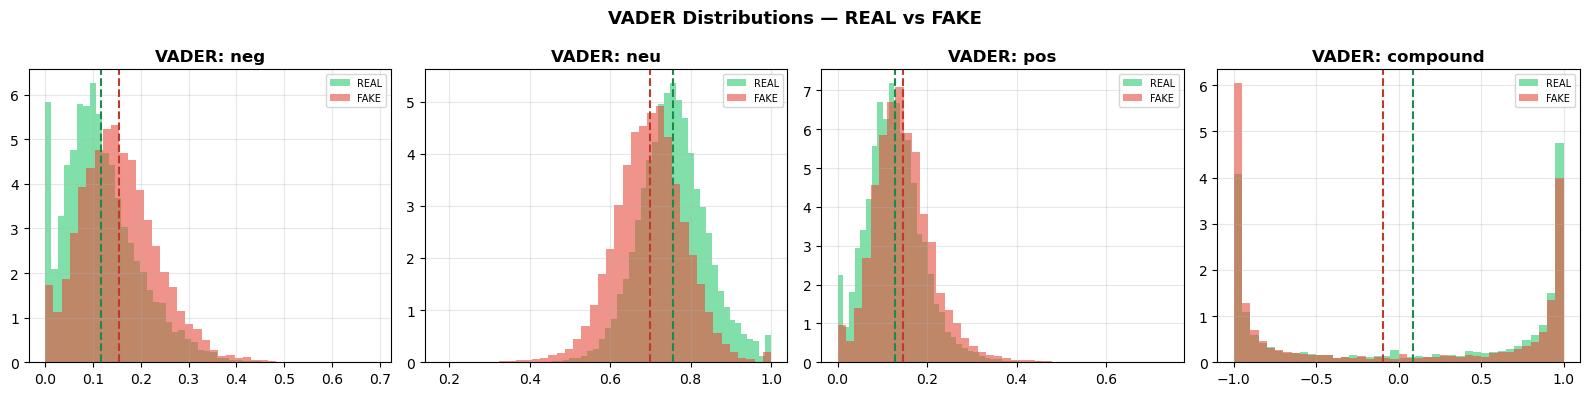

  [Saved] vader_distributions.png


In [16]:
print("=" * 72)
print("  STEP 1 — VADER SENTIMENT EXTRACTION (computed once, aligned)")
print("=" * 72)
 
sia = SentimentIntensityAnalyzer()
 
def get_vader_scores(text_series):
    scores = []
    for text in text_series:
        s = sia.polarity_scores(str(text))
        scores.append([s["neg"], s["neu"], s["pos"], s["compound"]])
    return np.array(scores, dtype=np.float32)
 
print("  Computing VADER scores for training set...")
vader_train = get_vader_scores(X_train_text)
print(f"  Train VADER shape : {vader_train.shape}")
print("  Computing VADER scores for test set...")
vader_test  = get_vader_scores(X_test_text)
print(f"  Test  VADER shape : {vader_test.shape}")
 
# Distribution analysis
vader_cols = ["neg", "neu", "pos", "compound"]
print(f"\n  VADER Score Distribution:")
print(f"  {'Score':<12} {'REAL_mean':>10} {'FAKE_mean':>10} {'|Δ|':>9}  Flag")
print("  " + "─" * 50)
for i, col in enumerate(vader_cols):
    rm = vader_train[y_train_arr=="REAL", i].mean()
    fm = vader_train[y_train_arr=="FAKE", i].mean()
    print(f"  {col:<12} {rm:>10.4f} {fm:>10.4f} {abs(rm-fm):>9.4f}  "
          f"{'◄ discriminative' if abs(rm-fm)>0.01 else ''}")
 
# VADER distribution plots
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, (ax, col) in enumerate(zip(axes, vader_cols)):
    ax.hist(vader_train[y_train_arr=="REAL", i], bins=40, alpha=0.6, color="#2ecc71", label="REAL", density=True)
    ax.hist(vader_train[y_train_arr=="FAKE", i], bins=40, alpha=0.6, color="#e74c3c", label="FAKE", density=True)
    ax.axvline(vader_train[y_train_arr=="REAL",i].mean(), color="#1a8a4e", linestyle="--", linewidth=1.5)
    ax.axvline(vader_train[y_train_arr=="FAKE",i].mean(), color="#c0392b", linestyle="--", linewidth=1.5)
    ax.set_title(f"VADER: {col}", fontweight="bold"); ax.legend(fontsize=7); ax.grid(alpha=0.3)
plt.suptitle("VADER Distributions — REAL vs FAKE", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.savefig("vader_distributions.png", dpi=150, bbox_inches="tight"); plt.show()
print("  [Saved] vader_distributions.png")
 
vader_train_sparse = csr_matrix(vader_train)
vader_test_sparse  = csr_matrix(vader_test)

In [17]:
all_hybrid_results = []
 
NGRAM_CONFIGS = [
    {"label":"1-gram", "ngram_range":(1,1), "min_df":3, "max_df":0.95, "cm_cmap":"Purples"},
    {"label":"2-gram", "ngram_range":(2,2), "min_df":5, "max_df":0.90, "cm_cmap":"RdPu"},
]
 
for ngram_cfg in NGRAM_CONFIGS:
    ngram_label = ngram_cfg["label"]
    print("\n" + "▓" * 72)
    print(f"  HYBRID: {ngram_label} + VADER — 4 vocab sizes × 4 classifiers")
    print("▓" * 72)
 
    for session_num, vocab_size in enumerate(VOCAB_SESSIONS, 1):
        print(f"\n  {ngram_label}+VADER | Session {session_num}/4 | vocab={vocab_size:,}")
 
        vec = TfidfVectorizer(
            ngram_range=ngram_cfg["ngram_range"], max_features=vocab_size,
            sublinear_tf=True, strip_accents="unicode", analyzer="word",
            stop_words="english", min_df=ngram_cfg["min_df"], max_df=ngram_cfg["max_df"]
        )
        X_tfidf_tr = vec.fit_transform(X_train_text)
        X_tfidf_te = vec.transform(X_test_text)
        feat_names = vec.get_feature_names_out()
        actual_v   = len(feat_names)
 
        X_hyb_tr = hstack([X_tfidf_tr, vader_train_sparse])
        X_hyb_te = hstack([X_tfidf_te, vader_test_sparse])
        print(f"  Hybrid shape: {X_hyb_tr.shape} ({actual_v} TF-IDF + 4 VADER)")
 
        # ── Hybrid Relevance Table ─────────────────────────────────────────
        mean_h = np.array(X_tfidf_tr.mean(axis=0)).flatten()
        top_h_idx  = mean_h.argsort()[::-1][:min(DISPLAY_WORDS, actual_v)]
        top_h_cols = feat_names[top_h_idx].tolist()
        real_lh, fake_lh = stratified_display_sample(y_train_arr, n_each=DISPLAY_N//2)
        disp_h_idx = real_lh + fake_lh
        samp_h_lab = [y_train_arr[i] for i in disp_h_idx]
        X_tfidf_disp = X_tfidf_tr[disp_h_idx][:, top_h_idx].toarray()
        X_vader_disp = vader_train[disp_h_idx]
        hyb_disp = pd.concat([
            pd.DataFrame(X_tfidf_disp, columns=top_h_cols),
            pd.DataFrame(X_vader_disp, columns=["VADER_neg","VADER_neu","VADER_pos","VADER_compound"])
        ], axis=1)
        hyb_disp.insert(0, "label", samp_h_lab)
        hyb_disp.insert(0, "article_id", range(1, DISPLAY_N+1))
        hyb_disp.to_csv(f"hybrid_relevance_table_{ngram_label}_vocab{vocab_size}.csv", index=False)
        print(f"  [Saved] hybrid_relevance_table_{ngram_label}_vocab{vocab_size}.csv")
 
        X_tr_h = X_hyb_tr.toarray()
        X_te_h = X_hyb_te.toarray()
 
        for model_name, model in get_models():
            print(f"\n  ── {model_name} | {ngram_label}+VADER | vocab={vocab_size:,} ──")
            res = evaluate_model(model, X_tr_h, X_te_h, y_train, y_test)
            print(f"  Accuracy={res['accuracy']:.4f}  F1={res['f1']:.4f}")
            print(classification_report(y_test, res["y_pred"],
                                        target_names=["FAKE","REAL"], digits=4, zero_division=0))
            plot_cm(y_test, res["y_pred"],
                    f"{model_name} | {ngram_label}+VADER | vocab={vocab_size:,}",
                    f"cm_hybrid_{ngram_label}_{model_name.replace(' ','_')}_vocab{vocab_size}.png",
                    cmap=ngram_cfg["cm_cmap"])
            all_hybrid_results.append({
                "Session": session_num, "Vocab Size": vocab_size,
                "N-gram": f"{ngram_label}+VADER", "Model": model_name,
                "Accuracy": round(res["accuracy"],4), "Precision": round(res["precision"],4),
                "Recall": round(res["recall"],4), "F1-Score": round(res["f1"],4),
                "y_pred_stored": res["y_pred"],
            })
        print(f"  ✓ {ngram_label}+VADER Session {session_num}/4 complete.")
 
print("\n  All hybrid sessions complete.")


▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  HYBRID: 1-gram + VADER — 4 vocab sizes × 4 classifiers
▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓

  1-gram+VADER | Session 1/4 | vocab=500
  Hybrid shape: (30837, 504) (500 TF-IDF + 4 VADER)
  [Saved] hybrid_relevance_table_1-gram_vocab500.csv

  ── Random Forest | 1-gram+VADER | vocab=500 ──
  Accuracy=0.9966  F1=0.9966
              precision    recall  f1-score   support

        FAKE     0.9983    0.9943    0.9963      3525
        REAL     0.9952    0.9986    0.9969      4185

    accuracy                         0.9966      7710
   macro avg     0.9968    0.9964    0.9966      7710
weighted avg     0.9966    0.9966    0.9966      7710

  [Saved] cm_hybrid_1-gram_Random_Forest_vocab500.png

  ── SVM | 1-gram+VADER | vocab=500 ──
  Accuracy=0.9944  F1=0.9944
              precision    recall  f1-score   support

        FAKE     0.9963    0.9915    0.9939      3525
        REA

## Phase 8 — Master Comparison Table (64 configurations)

In [18]:
# Merge all results
hybrid_df = pd.DataFrame(all_hybrid_results)
keep_cols = ["Session","Vocab Size","N-gram","Model","Accuracy","Precision","Recall","F1-Score"]
 
prev_1gram = pd.DataFrame(all_session_results)
prev_2gram = pd.DataFrame(all_2gram_results)
 
master_df = pd.concat(
    [prev_1gram[keep_cols], prev_2gram[keep_cols], hybrid_df[keep_cols]],
    ignore_index=True
)
 
ngram_order = {"1-gram":0, "2-gram":1, "1-gram+VADER":2, "2-gram+VADER":3}
model_order = {"Random Forest":0, "SVM":1, "Logistic Regression":2, "AdaBoost":3}
master_df["ng_sort"] = master_df["N-gram"].map(ngram_order)
master_df["mo_sort"] = master_df["Model"].map(model_order)
master_df = master_df.sort_values(["Vocab Size","ng_sort","mo_sort"]).drop(["ng_sort","mo_sort"],axis=1).reset_index(drop=True)
 
master_df.to_csv("master_comparison_all_64_configs.csv", index=False)
 
print("\n" + "=" * 86)
print("  MASTER TABLE — 4 feature sets × 4 vocab × 4 classifiers = 64 configurations")
print("=" * 86)
print(f"  {'Vocab':>8}  {'N-gram':<18} {'Model':<22} {'Accuracy':>10} {'F1':>10}")
print("  " + "─" * 72)
prev_v = None
for _, row in master_df.iterrows():
    if row["Vocab Size"] != prev_v:
        if prev_v is not None: print("  " + "─" * 72)
        prev_v = row["Vocab Size"]
    print(f"  {row['Vocab Size']:>8,}  {row['N-gram']:<18} {row['Model']:<22} "
          f"{row['Accuracy']:>10.4f} {row['F1-Score']:>10.4f}")
 
print("\n  [Saved] master_comparison_all_64_configs.csv")
 
# Best per classifier
print("\n" + "=" * 72)
print("  BEST CONFIGURATION PER CLASSIFIER")
print("=" * 72)
for mn in ["Random Forest","SVM","Logistic Regression","AdaBoost"]:
    sub = master_df[master_df["Model"]==mn]
    if sub.empty: continue
    best = sub.loc[sub["F1-Score"].idxmax()]
    print(f"  {mn:<22} → F1={best['F1-Score']:.4f}  Acc={best['Accuracy']:.4f}")
    print(f"    Feature set : {best['N-gram']}  |  Vocab : {best['Vocab Size']:,}")


  MASTER TABLE — 4 feature sets × 4 vocab × 4 classifiers = 64 configurations
     Vocab  N-gram             Model                    Accuracy         F1
  ────────────────────────────────────────────────────────────────────────
       500  1-gram             Random Forest              0.9966     0.9966
       500  1-gram             SVM                        0.9944     0.9944
       500  1-gram             Logistic Regression        0.9883     0.9883
       500  1-gram             AdaBoost                   0.9965     0.9965
       500  2-gram             Random Forest              0.9559     0.9558
       500  2-gram             SVM                        0.9626     0.9626
       500  2-gram             Logistic Regression        0.9621     0.9621
       500  2-gram             AdaBoost                   0.9355     0.9356
       500  1-gram+VADER       Random Forest              0.9966     0.9966
       500  1-gram+VADER       SVM                        0.9944     0.9944
       500

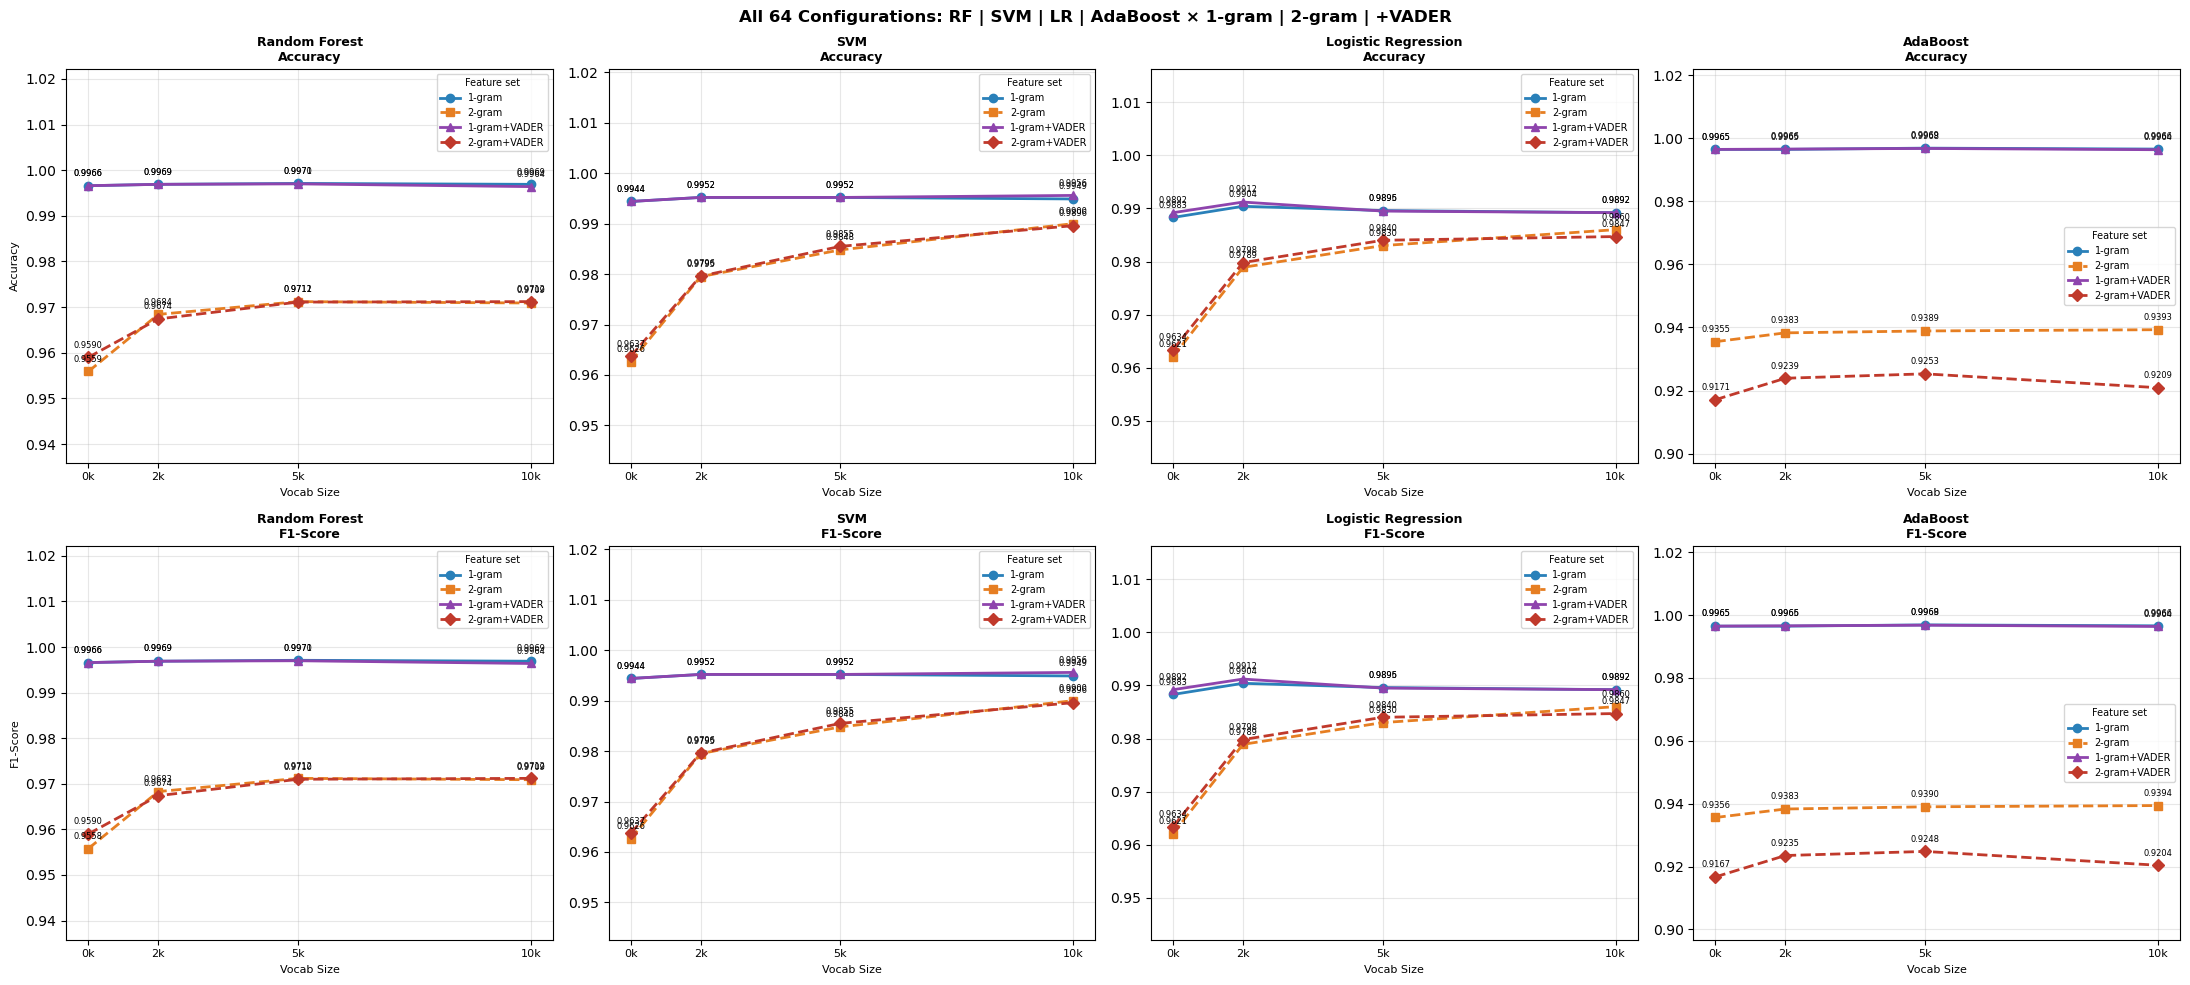

  [Saved] master_comparison_chart_64configs.png


In [19]:
MODEL_STYLES = {
    "Random Forest"      : {"color":"#2980b9","marker":"o","ls":"-"},
    "SVM"                : {"color":"#e67e22","marker":"s","ls":"-"},
    "Logistic Regression": {"color":"#27ae60","marker":"^","ls":"--"},
    "AdaBoost"           : {"color":"#8e44ad","marker":"D","ls":"--"},
}
feature_sets_all = ["1-gram","2-gram","1-gram+VADER","2-gram+VADER"]
fs_colors = ["#2980b9","#e67e22","#8e44ad","#c0392b"]
fs_ls     = ["-o","--s","-^","--D"]
 
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
for row_i, metric in enumerate(["Accuracy","F1-Score"]):
    for col_i, mn in enumerate(list(MODEL_STYLES.keys())):
        ax = axes[row_i][col_i]
        for fs, color, ls in zip(feature_sets_all, fs_colors, fs_ls):
            sub = master_df[(master_df["N-gram"]==fs)&(master_df["Model"]==mn)].sort_values("Vocab Size")
            if sub.empty: continue
            ax.plot(sub["Vocab Size"], sub[metric], ls, label=fs, color=color, linewidth=2, markersize=6)
            for _, r in sub.iterrows():
                ax.annotate(f"{r[metric]:.4f}",(r["Vocab Size"],r[metric]),
                            textcoords="offset points",xytext=(0,7),ha="center",fontsize=6)
        ax.set_title(f"{mn}\n{metric}", fontweight="bold", fontsize=9)
        ax.set_xlabel("Vocab Size", fontsize=8); ax.set_ylabel(metric if col_i==0 else "", fontsize=8)
        ax.set_xticks(VOCAB_SESSIONS)
        ax.set_xticklabels([f"{v//1000}k" for v in VOCAB_SESSIONS], fontsize=8)
        ax.legend(fontsize=7, title="Feature set", title_fontsize=7)
        ax.grid(alpha=0.3)
        vals = master_df[master_df["Model"]==mn][metric].values
        if len(vals): ax.set_ylim(vals.min()-0.02, vals.max()+0.025)
 
plt.suptitle("All 64 Configurations: RF | SVM | LR | AdaBoost × 1-gram | 2-gram | +VADER",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("master_comparison_chart_64configs.png", dpi=150, bbox_inches="tight")
plt.show()
print("  [Saved] master_comparison_chart_64configs.png")

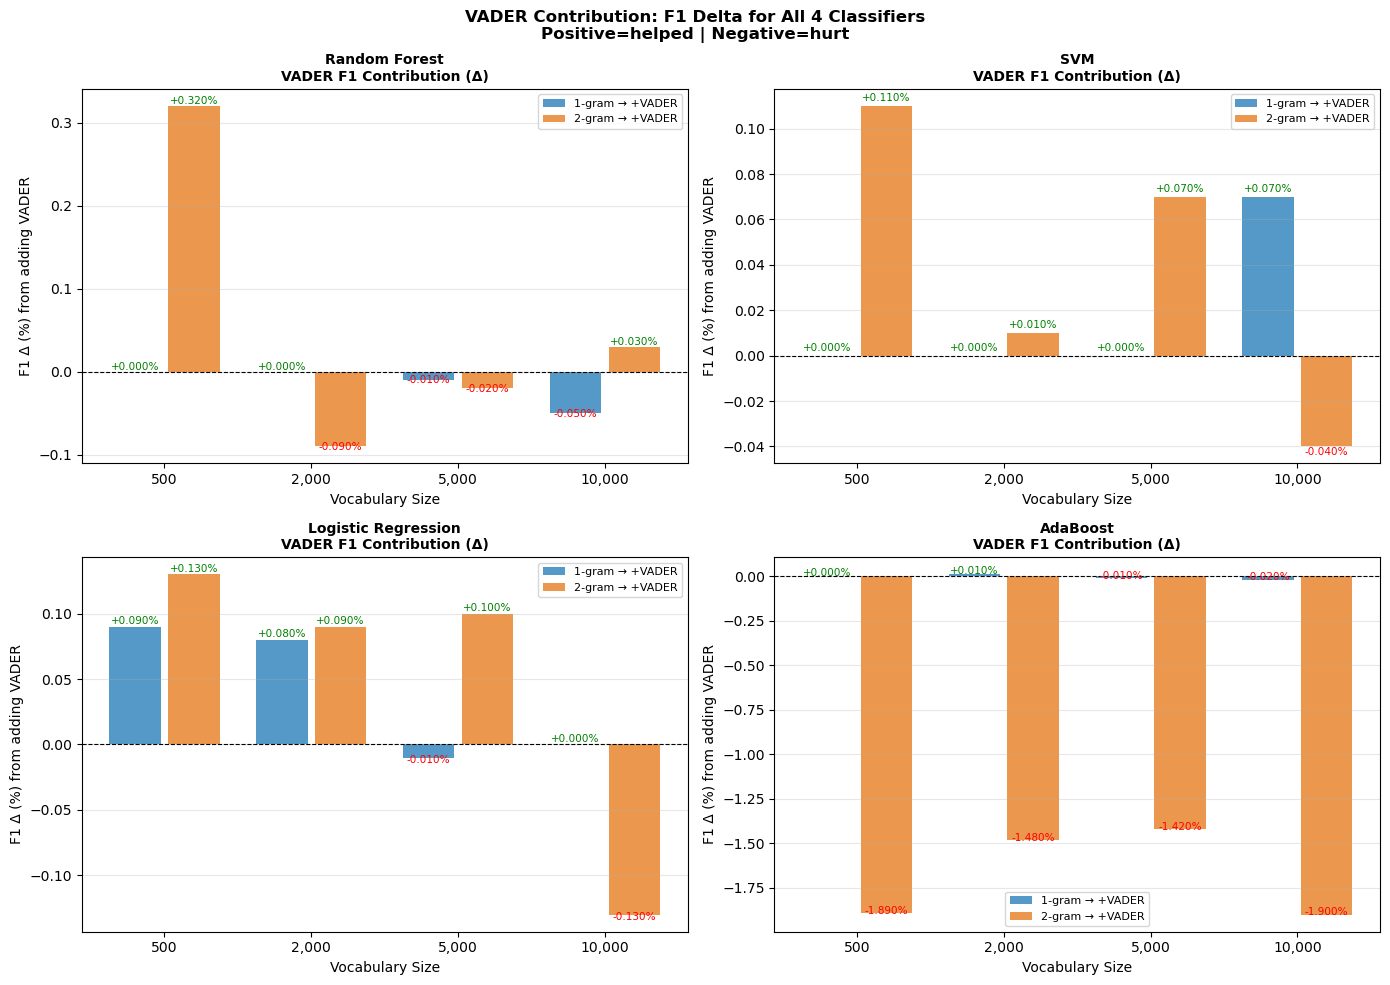

  [Saved] vader_contribution_delta_all_models.png


In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, mn in zip(axes.flatten(), list(MODEL_STYLES.keys())):
    for ngram_base, color, label in [
        ("1-gram","#2980b9","1-gram → +VADER"),
        ("2-gram","#e67e22","2-gram → +VADER"),
    ]:
        base   = master_df[(master_df["N-gram"]==ngram_base)&(master_df["Model"]==mn)].set_index("Vocab Size")
        hybrid = master_df[(master_df["N-gram"]==f"{ngram_base}+VADER")&(master_df["Model"]==mn)].set_index("Vocab Size")
        common = sorted(set(base.index) & set(hybrid.index))
        if not common: continue
        deltas = [hybrid.loc[v,"F1-Score"] - base.loc[v,"F1-Score"] for v in common]
        offset = -0.2 if ngram_base=="1-gram" else 0.2
        ax.bar([i+offset for i in range(len(common))], [d*100 for d in deltas],
               0.35, color=color, alpha=0.8, label=label)
        for j,d in enumerate(deltas):
            ax.text(j+offset, d*100+(0.002 if d>=0 else -0.004), f"{d*100:+.3f}%",
                    ha="center", fontsize=7.5, color="green" if d>=0 else "red")
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_title(f"{mn}\nVADER F1 Contribution (Δ)", fontweight="bold", fontsize=10)
    ax.set_xticks(range(len(VOCAB_SESSIONS)))
    ax.set_xticklabels([f"{v:,}" for v in VOCAB_SESSIONS])
    ax.set_xlabel("Vocabulary Size"); ax.set_ylabel("F1 Δ (%) from adding VADER")
    ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)
plt.suptitle("VADER Contribution: F1 Delta for All 4 Classifiers\nPositive=helped | Negative=hurt",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("vader_contribution_delta_all_models.png", dpi=150, bbox_inches="tight")
plt.show()
print("  [Saved] vader_contribution_delta_all_models.png")

## Phase 9 — Confusion Matrices (all 64 configurations)

In [21]:
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
 
FEATURE_SETS_CM = ["1-gram","2-gram","1-gram+VADER","2-gram+VADER"]
MODELS_CM = ["Random Forest","SVM","Logistic Regression","AdaBoost"]
 
CM_PALETTES = {
    "1-gram"       : {"cmap":"Blues",   "accent":"#185FA5"},
    "2-gram"       : {"cmap":"Oranges", "accent":"#854F0B"},
    "1-gram+VADER" : {"cmap":"Greens",  "accent":"#0F6E56"},
    "2-gram+VADER" : {"cmap":"RdPu",    "accent":"#993556"},
}
CM_COLORS_MODEL = {
    "Random Forest"      : "Blues",
    "SVM"                : "Oranges",
    "Logistic Regression": "Greens",
    "AdaBoost"           : "Purples",
}
 
def draw_cm(ax, y_true, y_pred, title, feature_set, is_best=False):
    cm = confusion_matrix(y_true, y_pred, labels=["FAKE","REAL"])
    cmap   = CM_PALETTES[feature_set]["cmap"]
    accent = CM_PALETTES[feature_set]["accent"]
    ax.imshow(cm, interpolation="nearest", cmap=cmap, aspect="auto")
    cell_lbl = [["TP","FN"],["FP","TN"]]
    thresh = cm.max()/2.0
    for i in range(2):
        for j in range(2):
            col = "white" if cm[i,j]>thresh else "#1a1a1a"
            ax.text(j,i,f"{cm[i,j]:,}",ha="center",va="center",fontsize=10,fontweight="bold",color=col)
            ax.text(j,i+0.28,cell_lbl[i][j],ha="center",va="center",fontsize=7,color=col,alpha=0.85)
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(["Pred\nFAKE","Pred\nREAL"],fontsize=7)
    ax.set_yticklabels(["Act\nFAKE","Act\nREAL"],fontsize=7,rotation=90,va="center")
    ax.tick_params(length=0)
    for spine in ax.spines.values():
        spine.set_edgecolor(accent); spine.set_linewidth(2.5 if is_best else 1.0)
    best_tag = " ★BEST" if is_best else ""
    ax.set_title(f"{title}{best_tag}", fontsize=7.5, fontweight="bold", color=accent, pad=4)
    tn,fp,fn,tp = cm.ravel()
    acc = (tp+tn)/(tp+tn+fp+fn)
    ax.set_xlabel(f"Acc={acc*100:.2f}%  FP={fp:,}  FN={fn:,}", fontsize=6.5, labelpad=3)
 
print("  ✓  CM helpers defined.")

  ✓  CM helpers defined.


  Re-training 1-gram and 2-gram to collect predictions for CM plots...
  Done: 1-gram vocab=500
  Done: 2-gram vocab=500
  Done: 1-gram vocab=2,000
  Done: 2-gram vocab=2,000
  Done: 1-gram vocab=5,000
  Done: 2-gram vocab=5,000
  Done: 1-gram vocab=10,000
  Done: 2-gram vocab=10,000

  ★ Best: (5000, '1-gram', 'Random Forest')  Acc=0.9971


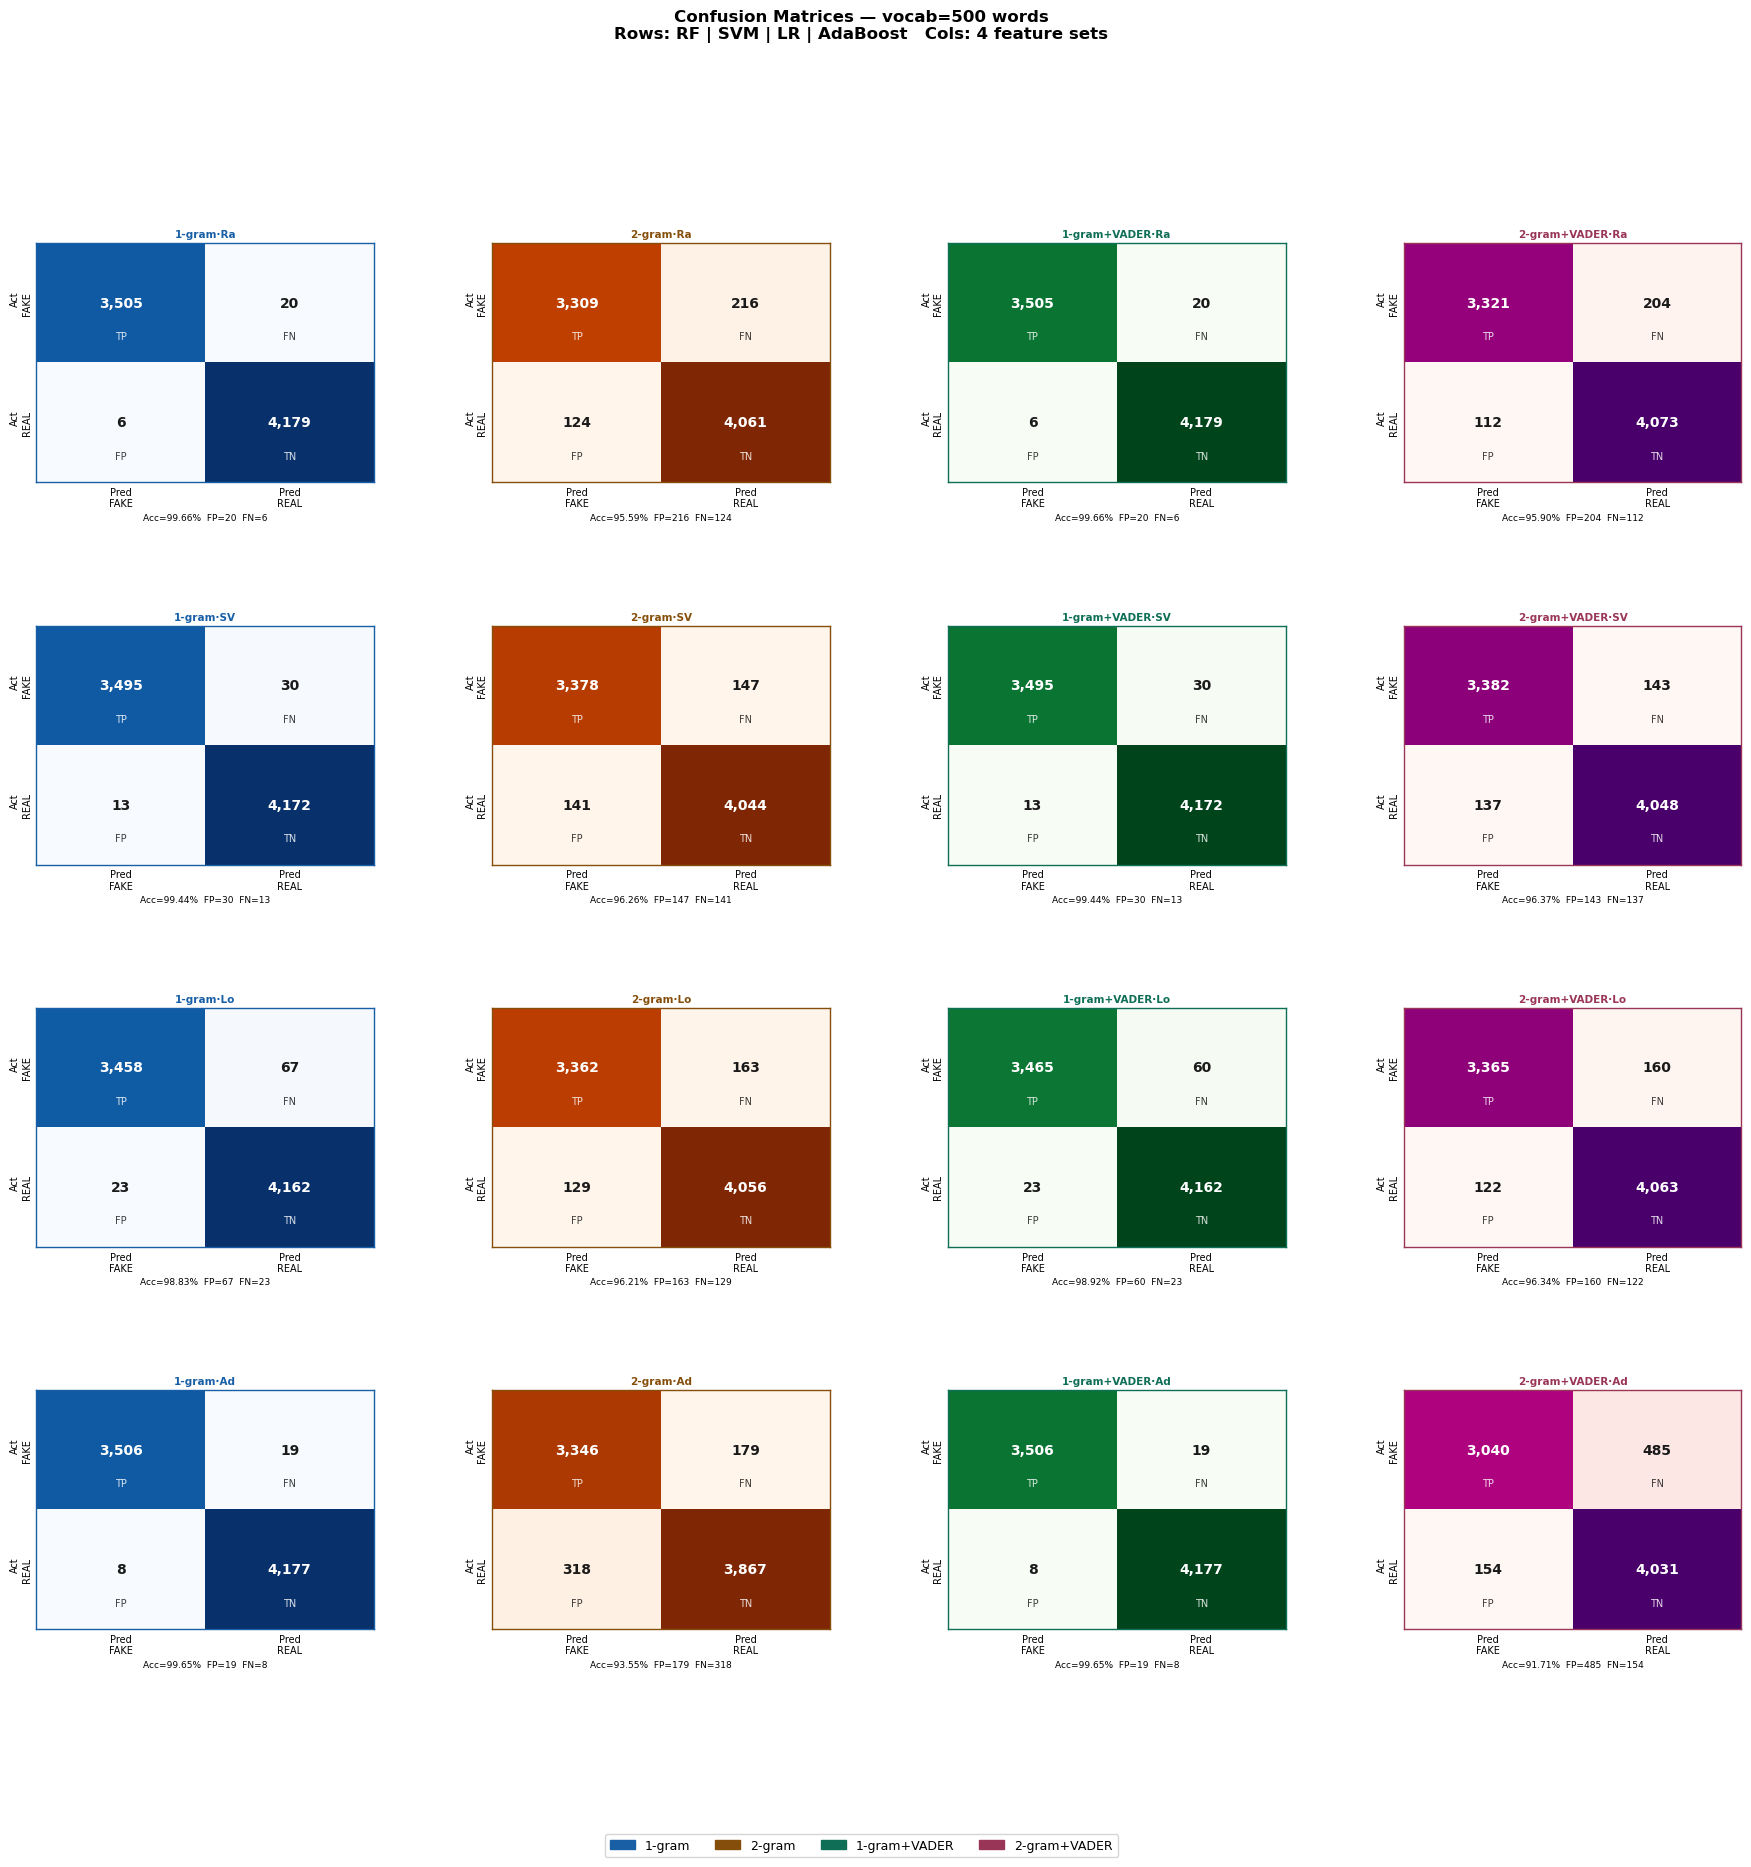

  [Saved] cm_grid_vocab500.png


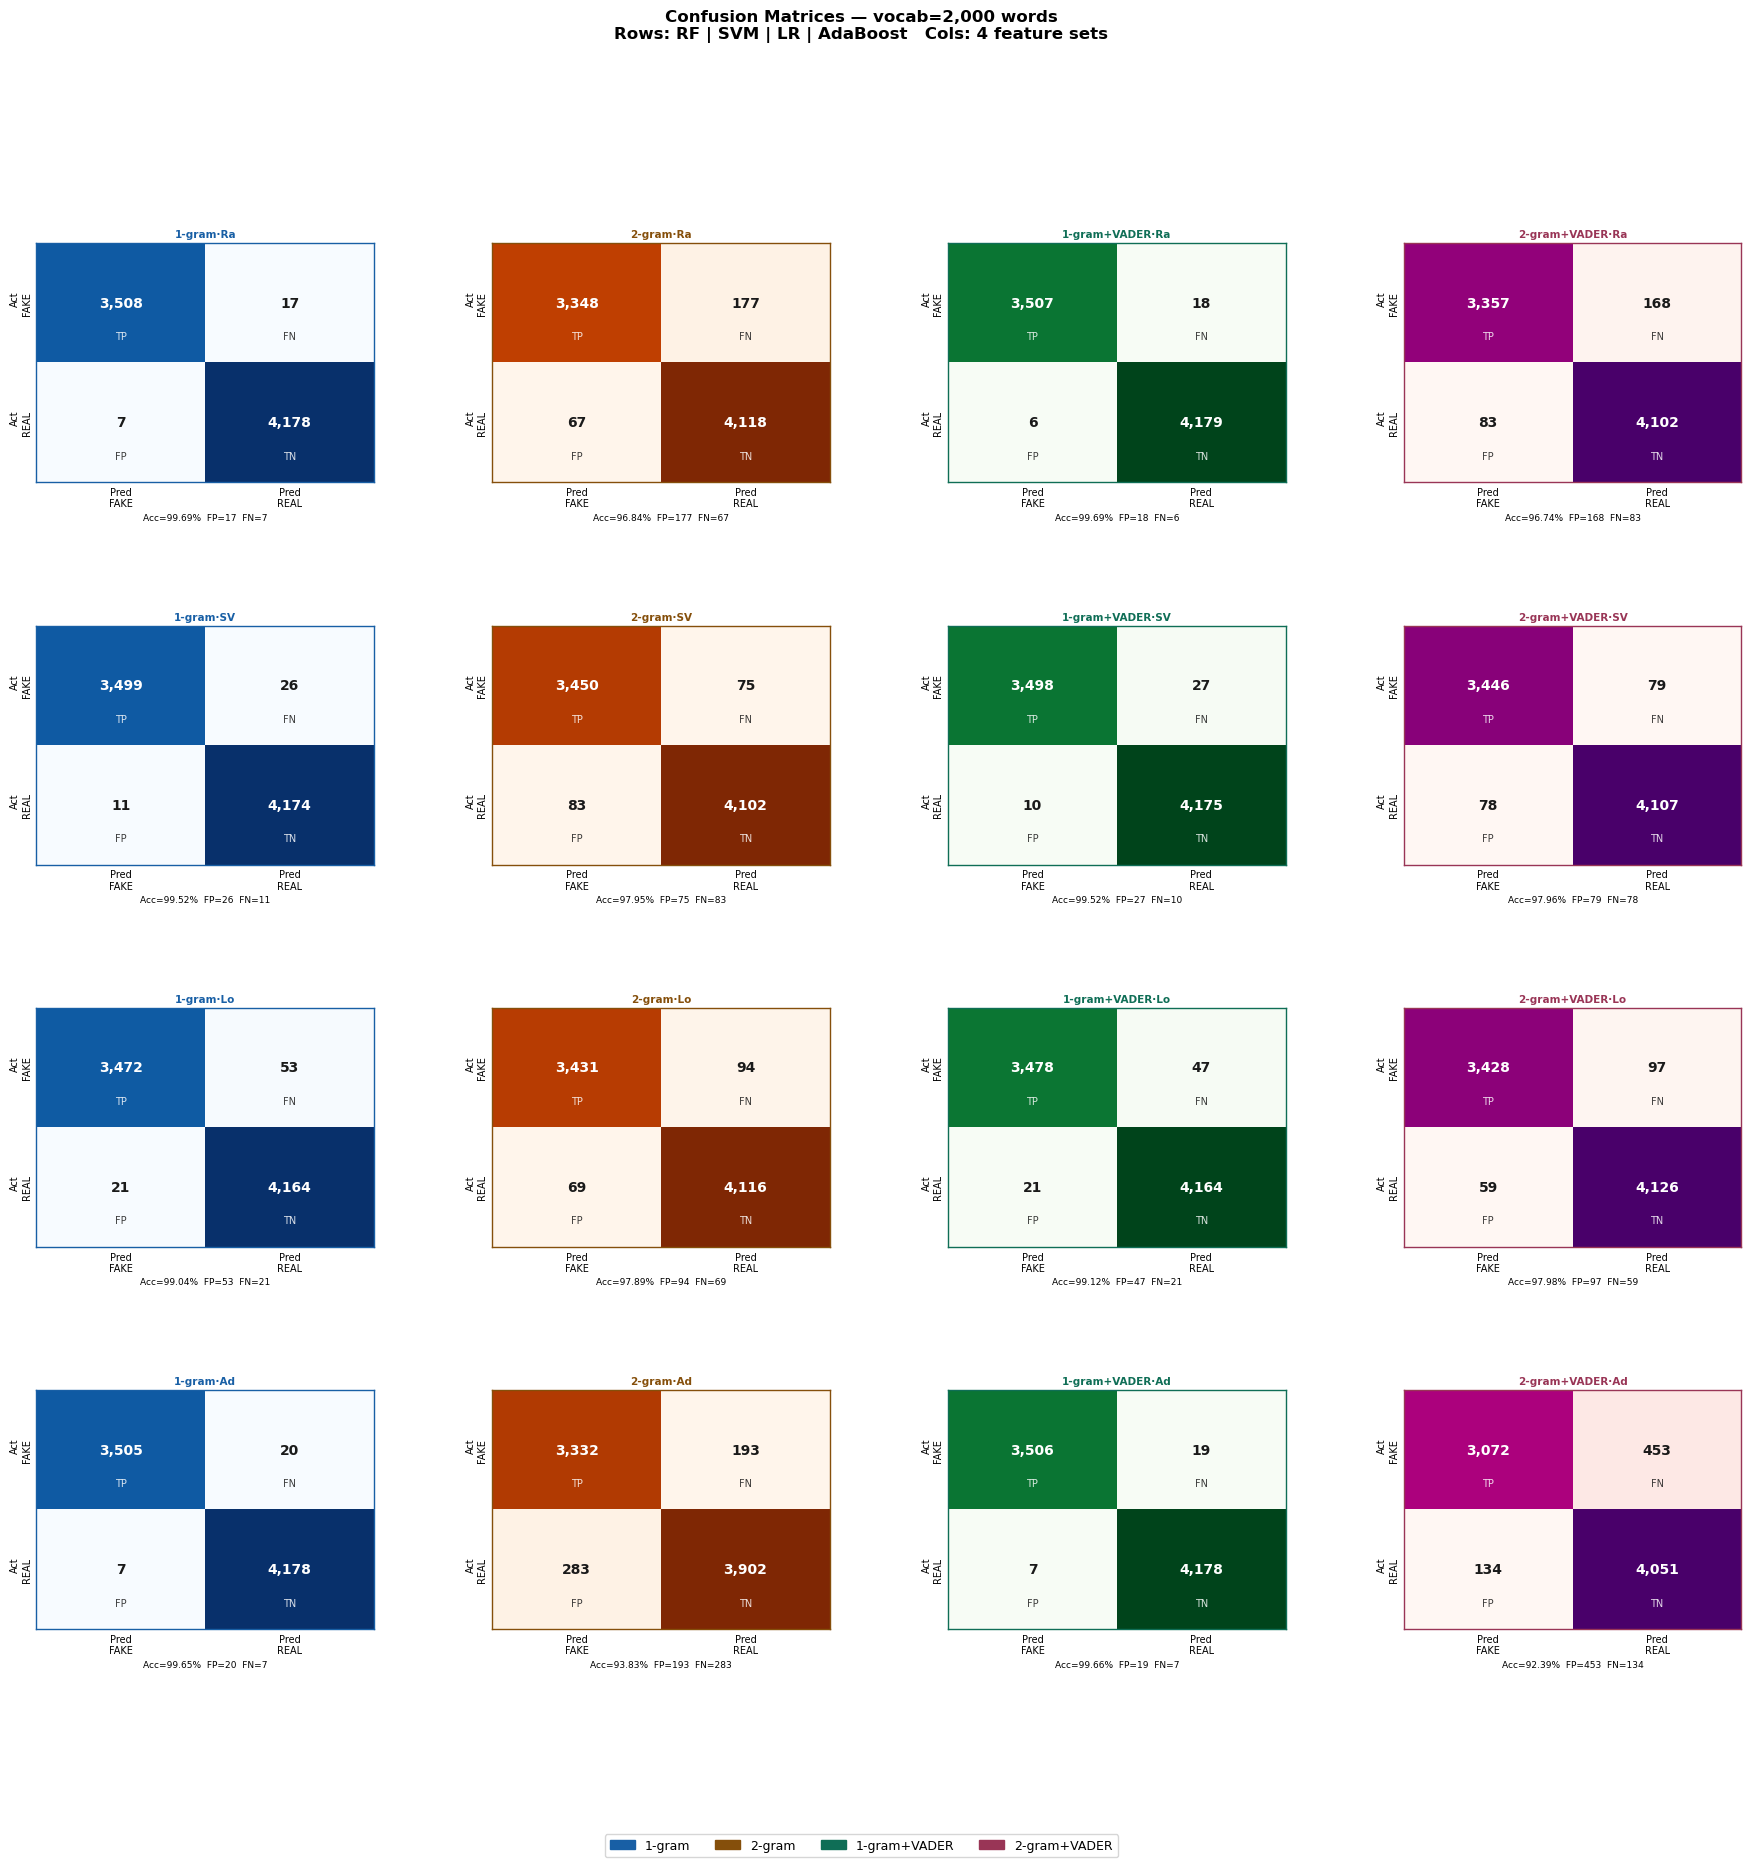

  [Saved] cm_grid_vocab2000.png


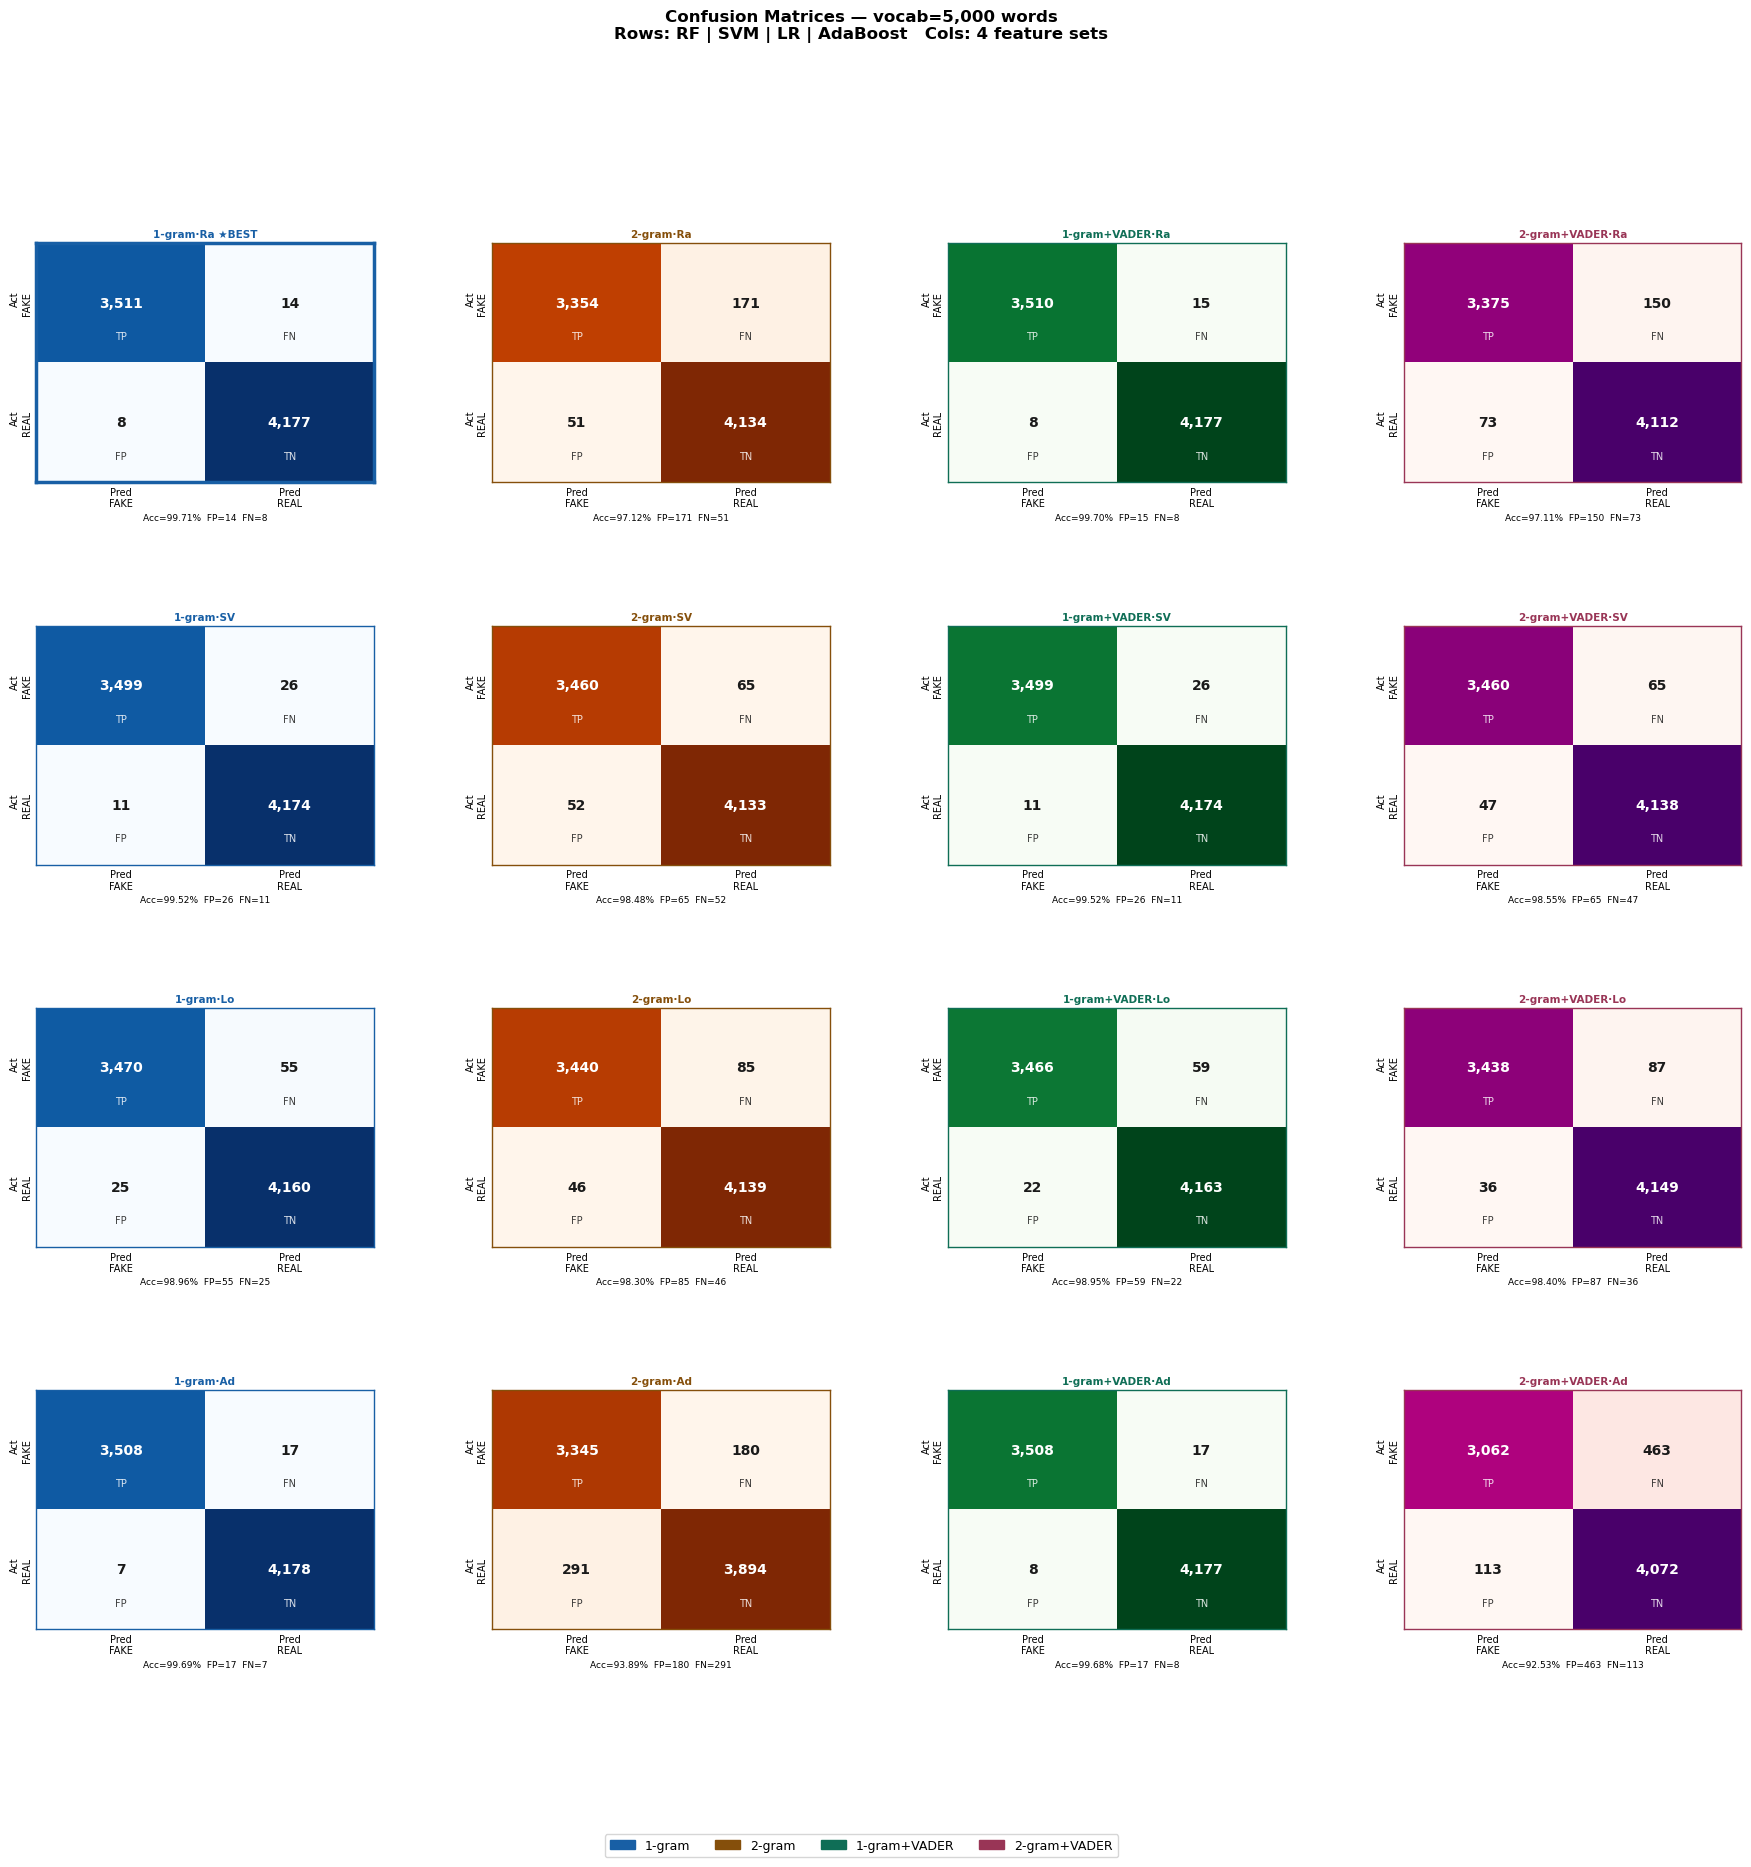

  [Saved] cm_grid_vocab5000.png


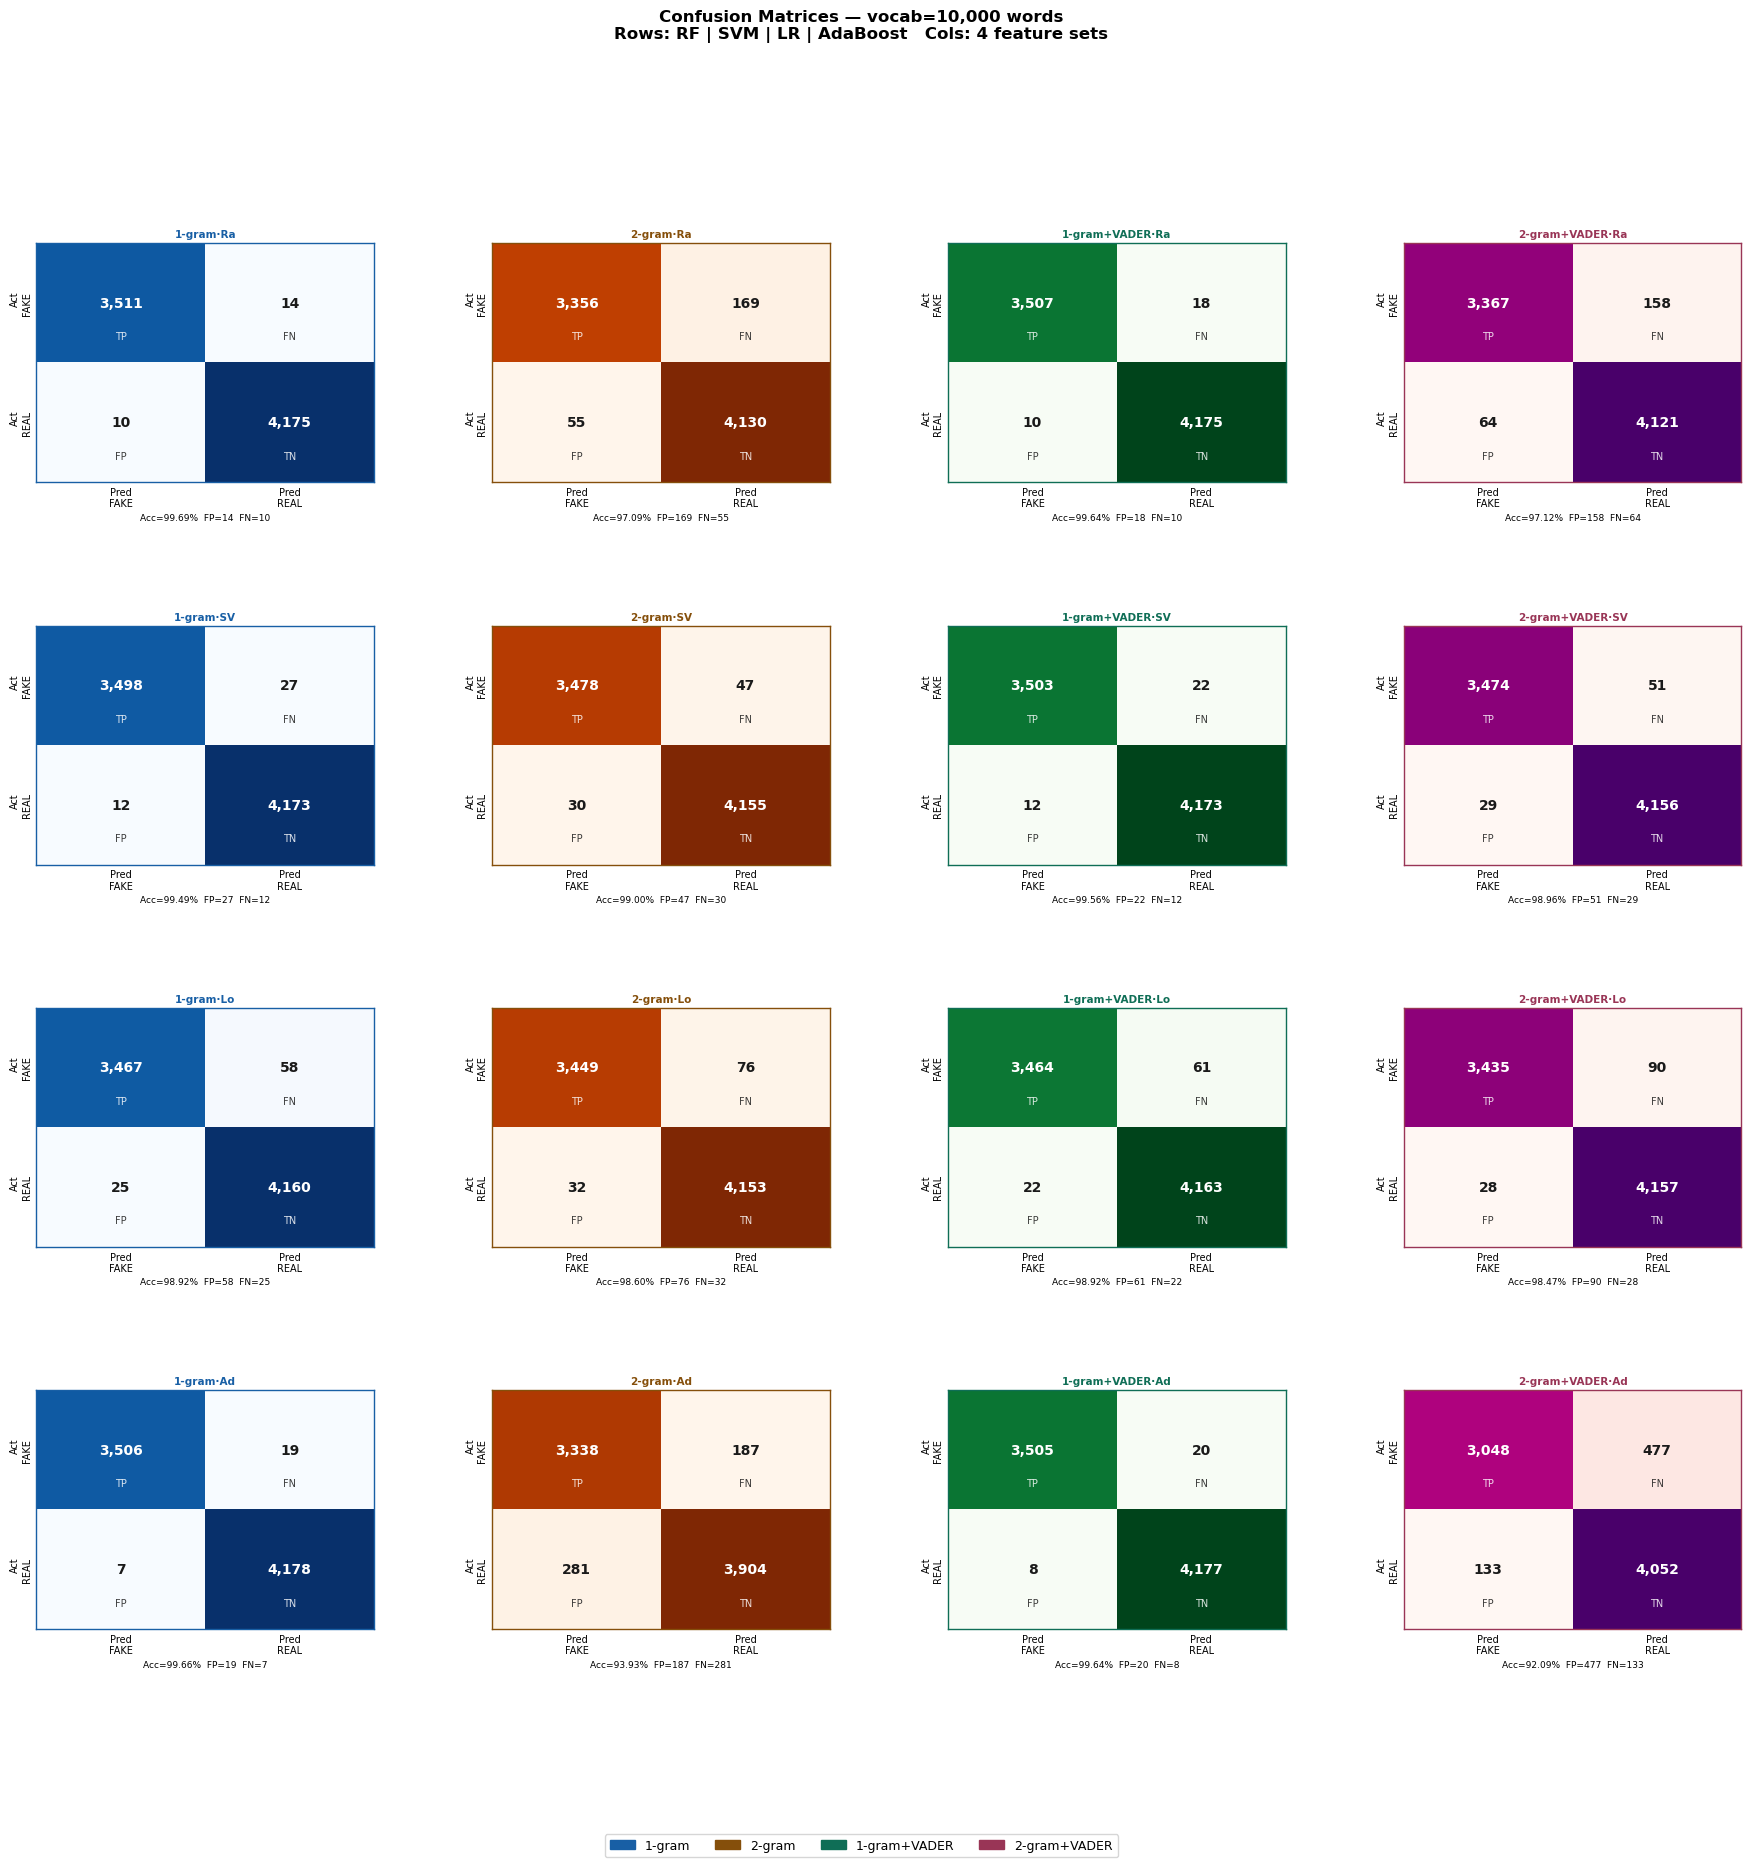

  [Saved] cm_grid_vocab10000.png


In [22]:
# ── Grid per vocab size: rows=models, cols=feature sets ──────────────────────
# Collect all predictions from master loop results
# We need to re-train to get predictions for all 64 configs
# (or use stored y_pred_stored from all_hybrid_results + all_session_results)
 
all_preds = {}  # key=(vocab, feature_set, model) → y_pred
 
# From 1-gram results
for r in all_session_results:
    # Re-train to recover y_pred (clean approach)
    pass
 
# Faster: collect stored preds from hybrid loop + re-run 1gram/2gram
for r in all_hybrid_results:
    key = (r["Vocab Size"], r["N-gram"], r["Model"])
    if "y_pred_stored" in r:
        all_preds[key] = r["y_pred_stored"]
 
print("  Re-training 1-gram and 2-gram to collect predictions for CM plots...")
for vocab_size in VOCAB_SESSIONS:
    for ng_label, ng_range, ng_mindf, ng_maxdf in [
        ("1-gram",(1,1),3,0.95),
        ("2-gram",(2,2),5,0.90),
    ]:
        vec_cm = TfidfVectorizer(
            ngram_range=ng_range, max_features=vocab_size, sublinear_tf=True,
            strip_accents="unicode", analyzer="word", stop_words="english",
            min_df=ng_mindf, max_df=ng_maxdf
        )
        X_tr_cm = vec_cm.fit_transform(X_train_text).toarray()
        X_te_cm = vec_cm.transform(X_test_text).toarray()
        for mn, model in get_models():
            model.fit(X_tr_cm, y_train)
            all_preds[(vocab_size, ng_label, mn)] = model.predict(X_te_cm)
        print(f"  Done: {ng_label} vocab={vocab_size:,}")
 
# Find best config
best_key_cm = max(all_preds.keys(),
    key=lambda k: accuracy_score(y_test, all_preds[k]))
print(f"\n  ★ Best: {best_key_cm}  Acc={accuracy_score(y_test, all_preds[best_key_cm]):.4f}")
 
# Plot 2×4 grids per vocab (rows=2 models RF+SVM, cols=4 feature sets)
for vocab_size in VOCAB_SESSIONS:
    fig, axes = plt.subplots(len(MODELS_CM), len(FEATURE_SETS_CM),
                             figsize=(22, 4.5*len(MODELS_CM)),
                             gridspec_kw={"hspace":0.6,"wspace":0.35})
    fig.suptitle(f"Confusion Matrices — vocab={vocab_size:,} words\n"
                 f"Rows: RF | SVM | LR | AdaBoost   Cols: 4 feature sets",
                 fontsize=12, fontweight="bold", y=1.01)
    for ri, mn in enumerate(MODELS_CM):
        for ci, fs in enumerate(FEATURE_SETS_CM):
            ax = axes[ri][ci]
            key = (vocab_size, fs, mn)
            if key in all_preds:
                is_best = key == best_key_cm
                draw_cm(ax, y_test, all_preds[key], f"{fs}·{mn[:2]}", fs, is_best)
            else:
                ax.axis("off"); ax.text(0.5,0.5,"N/A",ha="center",va="center")
    legend_patches = [mpatches.Patch(color=CM_PALETTES[fs]["accent"],label=fs) for fs in FEATURE_SETS_CM]
    fig.legend(handles=legend_patches, loc="lower center", ncol=4, fontsize=9, bbox_to_anchor=(0.5,-0.02))
    sp = f"cm_grid_vocab{vocab_size}.png"
    plt.savefig(sp, dpi=150, bbox_inches="tight"); plt.show()
    print(f"  [Saved] {sp}")

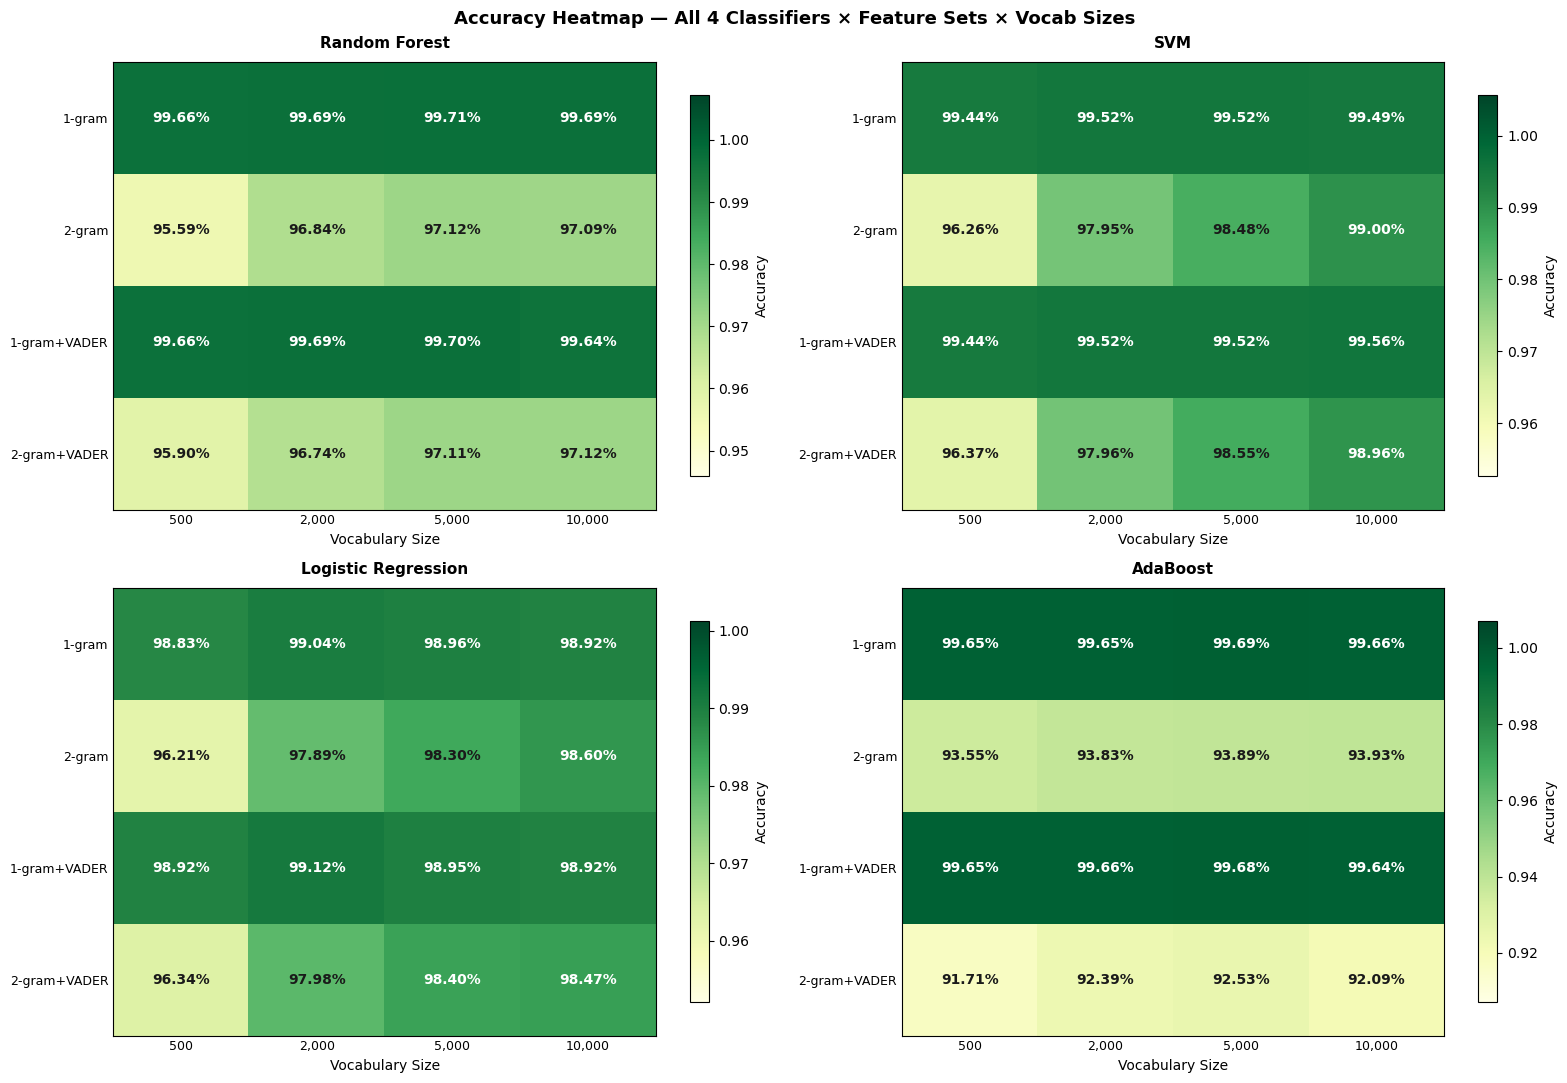

  [Saved] cm_accuracy_heatmap_all_models.png

  PIPELINE COMPLETE
  Total configurations trained: 64
  (4 feature sets × 4 vocab sizes × 4 classifiers)


In [23]:
# ── Accuracy Heatmap: feature sets × vocab sizes ─────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
for ax, mn in zip(axes.flatten(), MODELS_CM):
    matrix = np.zeros((len(FEATURE_SETS_CM), len(VOCAB_SESSIONS)))
    for ri, fs in enumerate(FEATURE_SETS_CM):
        for ci, vs in enumerate(VOCAB_SESSIONS):
            key = (vs, fs, mn)
            if key in all_preds:
                matrix[ri,ci] = accuracy_score(y_test, all_preds[key])
    im = ax.imshow(matrix, cmap="YlGn", vmin=matrix.min()-0.01, vmax=matrix.max()+0.01, aspect="auto")
    for ri in range(len(FEATURE_SETS_CM)):
        for ci in range(len(VOCAB_SESSIONS)):
            val = matrix[ri,ci]
            ax.text(ci,ri,f"{val*100:.2f}%",ha="center",va="center",fontsize=10,fontweight="bold",
                    color="white" if val>matrix.mean() else "#1a1a1a")
    ax.set_xticks(range(len(VOCAB_SESSIONS)))
    ax.set_xticklabels([f"{v:,}" for v in VOCAB_SESSIONS], fontsize=9)
    ax.set_yticks(range(len(FEATURE_SETS_CM)))
    ax.set_yticklabels(FEATURE_SETS_CM, fontsize=9)
    ax.set_xlabel("Vocabulary Size", fontsize=10)
    ax.set_title(mn, fontsize=11, fontweight="bold", pad=10); ax.tick_params(length=0)
    plt.colorbar(im, ax=ax, shrink=0.85, label="Accuracy")
plt.suptitle("Accuracy Heatmap — All 4 Classifiers × Feature Sets × Vocab Sizes",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("cm_accuracy_heatmap_all_models.png", dpi=150, bbox_inches="tight")
plt.show()
print("  [Saved] cm_accuracy_heatmap_all_models.png")
 
print("\n" + "=" * 72)
print("  PIPELINE COMPLETE")
print("  Total configurations trained: 64")
print("  (4 feature sets × 4 vocab sizes × 4 classifiers)")
print("=" * 72)